# Visión por Computadora II - Trabajo Final

## Integrantes

- Acevedo Zain, Gaspar (acevedo.zain.gaspar@gmail.com)
- Lauro, Rodrigo (ing.rodrigo.lauro@gmail.com)
- Rodrigues da Cruz, Nicolás (Nicolasrdc151@gmail.com)

## Descripción del problema

- Tipo de problema: Clasificación
- Descripción: Detección de nódulos pulmonares en tomografías de tórax.
- Detalles: Desarrollar un modelo de aprendizaje profundo que identifique la presencia de nódulos pulmonares en imágenes de tomografía computarizada (CT) de tórax.​
- Dataset: [Chest CT-Scan images Dataset](https://www.kaggle.com/datasets/mohamedhanyyy/chest-ctscan-images)

## Imports

In [2]:
!pip3 install torchinfo

import torchvision
from torchvision import datasets, transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

import torch
import cv2

import numpy as np
import pandas as pd

import os
from zipfile import ZipFile
from typing import Tuple
import math
import random

import matplotlib.pyplot as plt
from collections import Counter

from sklearn.decomposition import PCA

## Descarga del dataset

In [3]:
!curl -L -o "/content/dataset.zip" "https://www.kaggle.com/api/v1/datasets/download/mohamedhanyyy/chest-ctscan-images"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  118M  100  118M    0     0  81.6M      0  0:00:01  0:00:01 --:--:--  150M


In [4]:
zip_file = "/content/dataset.zip"
dataset_unzip_folder = "/content/."
dataset_folder = "/content/Data"
DATASET_TRAIN = os.path.join(dataset_folder, "train")
DATASET_TEST = os.path.join(dataset_folder, "test")
DATASET_VALID = os.path.join(dataset_folder, "valid")

In [5]:
# Descomprimo si NO existe la carpeta /content/dataset_emociones
if not os.path.isdir(dataset_folder):
  with ZipFile(zip_file, 'r') as zip_object:
    zip_object.extractall(path=dataset_unzip_folder)

## EDA


Primero definimos una transformación básica en donde se aplica la transformación [ToTensor](https://docs.pytorch.org/vision/main/generated/torchvision.transforms.ToTensor.html).

Esta permite convertir una imagen en un *tensor*, lo cual es necesario para trabajar con algunos modelos de PyTorch. También permite escalar los valores de píxeles originales (rango $[0; 255]$) al rango $[0; 1]$.

Por el momento solo se aplica esta transformación, ya que deseamos hacer un análisis inicial del dataset, pero en pasos posteriores se agregarán otras transformaciones según sea conveniente.



In [6]:
basic_transform = transforms.Compose([
    transforms.ToTensor(),
])

Se crean los datasets de `train`, `test` y `validation` utilizando la clase [ImageFolder](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.ImageFolder.html).

En cada uno se aplica la transformación base definida en `basic_transform`.

In [7]:
train_data = datasets.ImageFolder(root=DATASET_TRAIN, transform=basic_transform)
test_data = datasets.ImageFolder(root=DATASET_TEST, transform=basic_transform)
validation_data = datasets.ImageFolder(root=DATASET_VALID, transform=basic_transform)

En cada dataset se tienen las siguientes cantidades de imágenes:

- `Train`: $613$
- `Test`: $315$
- `Validation`: $72$

In [8]:
print(f"Cantidad de imágenes en Train: {len(train_data)}")
print(f"Cantidad de imágenes en Test: {len(test_data)}")
print(f"Cantidad de imágenes en Validation: {len(validation_data)}")

Cantidad de imágenes en Train: 613
Cantidad de imágenes en Test: 315
Cantidad de imágenes en Validation: 72


A continuación se definen las siguientes funciones:

- `get_class_counts`: dado un dataset formado mediante un `ImageFolder`, devuelve una lista con el nombre de las clases y otra con la cantidad de ocurrencias de cada una.
- `plot_image_class_distribution`: realiza un gráfico de cantidad de ocurrencias de cada clase en un dataset formado por `ImageFolder`.

In [9]:
def get_class_counts(dataset: ImageFolder) -> Tuple[list, list]:
  """
  Dado un dataset de tipo ImageFolder, devuelve las clases y
  su cantidad de ocurrencias.

  Args:
    dataset (ImageFolder): Dataset sobre el cual se obtendrán las
      clases y sus cantidades de ocurrencias.
  Returns:
    Tuple[list, list]: Devuelve dos listas:
      class_names: nombre de clases del dataset.
      counts: cantidad de ocurrencia de cada clase en el dataset.
  """
  class_labels = dataset.targets
  class_counts = Counter(class_labels)
  class_names = train_data.classes
  counts = [class_counts[i] for i in range(len(class_names))]

  return class_names, counts

In [10]:
def plot_image_class_distribution(dataset: ImageFolder,
                                  datasetName: str = "train",
                                  figsize: tuple = (10, 6)):
  """
  Grafica la distribución de clases de un dataset de imágenes.

  Args:
    dataset (ImageFolder): dataset cuyas clases se graficarán.
    datasetName (str): nombre del dataset, que se utilizará para el título
      del gráfico.
    figsize (tuple): tamaño del gráfico. Por defecto es (10, 6).
  """
  class_names, counts = get_class_counts(dataset=dataset)

  plt.figure(figsize=figsize)
  plt.barh(class_names, counts)
  plt.xlabel("Cantidad de imágenes")
  plt.ylabel("Clases")
  plt.title(f"Distribución de imágenes por clases en dataset {datasetName}")
  plt.tight_layout()
  plt.show()

### Distribuciones de clases en cada dataset

El dataset de train tiene la siguiente distribución de clases:

| Clase | Cantidad |
| --- | --- |
| `adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib` | $195$ |
| `large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa` | $115$ |
| `normal` | $148$ |
| `squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa` | $155$ |

Es decir, el dataset de `train` presenta un ligero desbalance de clases, siendo `adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib` la que mayor ocurrencias tiene, y `large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa` las que menos tiene.

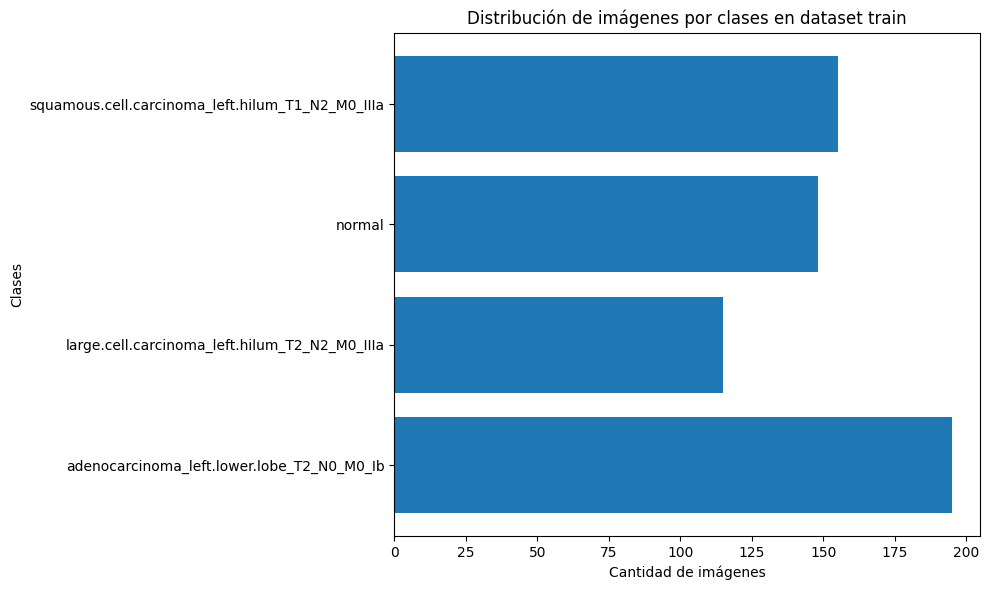

In [11]:
plot_image_class_distribution(dataset=train_data, datasetName="train")

El dataset de `test` tiene la siguiente distribución de clases:

| Clase | Cantidad |
| --- | --- |
| `adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib` | $120$ |
| `large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa` | $51$ |
| `normal` | $54$ |
| `squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa` | $90$ |

Es decir, el dataset de `test` presenta ligero desbalance de clases, siendo `adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib` la que mayor ocurrencias tiene.

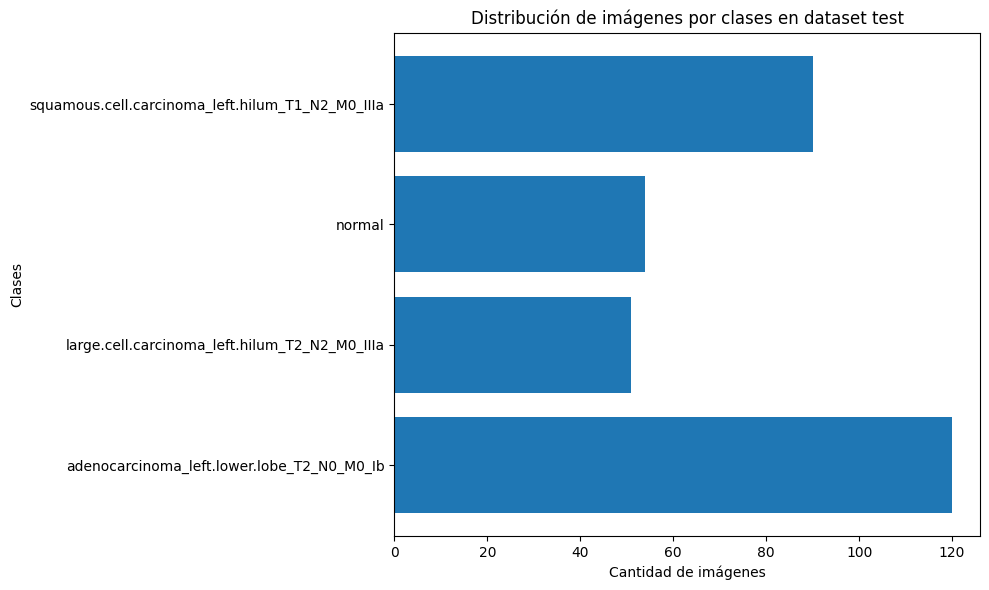

In [12]:
plot_image_class_distribution(dataset=test_data, datasetName="test")

El dataset de `validation` tiene la siguiente distribución de clases:

| Clase | Cantidad |
| --- | --- |
| `adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib` | $23$ |
| `large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa` | $21$ |
| `normal` | $13$ |
| `squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa` | $15$ |

Es decir, este dataset está ligeramente desbalanceado.

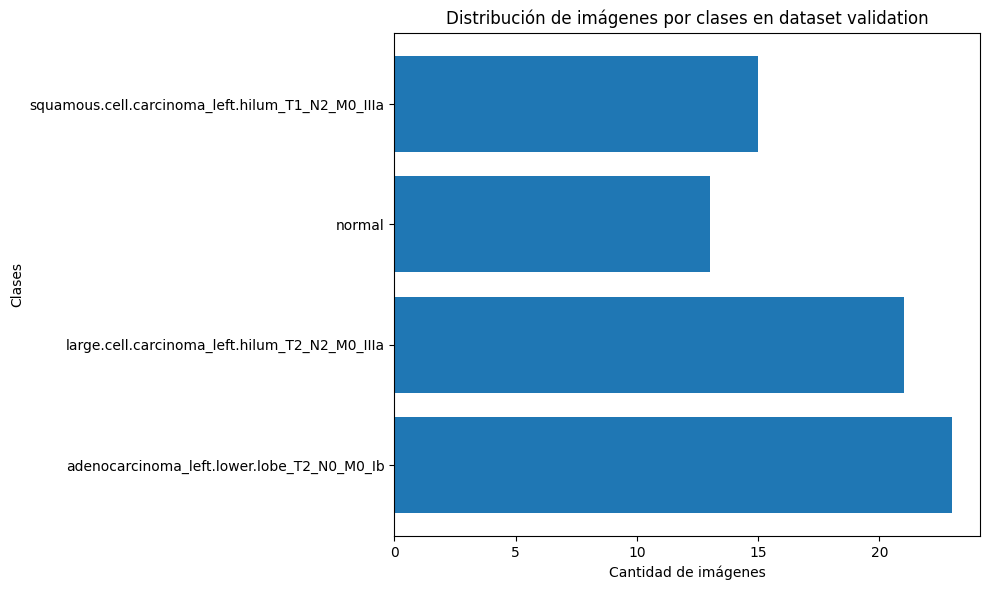

In [13]:
plot_image_class_distribution(dataset=validation_data, datasetName="validation")

### Análisis de dimensiones

En esta sección se analizan las dimensiones de las imágenes de los datasets de `train`, `test` y `validation`.

Comenzamos definiendo la función `get_shape_counts`, la cual devuelve las dimensiones de las imágenes de un dataset, como así también el *conteo* de sus ocurrencias.

Esto permitirá tener un primer acercamiento a las dimensiones de las imágenes de los datasets, que nos permitirá si todas tienen el mismo tamaño o no.

In [14]:
def get_shape_counts(dataset: ImageFolder) -> Counter:
  """
  Dado un dataset de tipo ImageFolder, devuelve las dimensiones de
  sus imágenes, junto la cantidad de ocurrencias.

  Args:
    dataset (ImageFolder): Dataset sobre el cual se obtendrán las
      clases y sus cantidades de ocurrencias.
  Returns:
    Counter: contador de ocurrencias de cada dimensión de imágen
    distinta en el dataset.
  """
  dataset_shapes = []

  for img in dataset:
    dataset_shapes.append(img[0].shape)

  dataset_counts = Counter(dataset_shapes)

  return dataset_counts

In [15]:
train_data_shape = get_shape_counts(dataset=train_data)
test_data_shape = get_shape_counts(dataset=test_data)
validation_data_shape = get_shape_counts(dataset=validation_data)

Para el dataset de `train` se observa que la mayoría de las imágenes tienen dimensiones distintas.

Solamente coinciden en la cantidad de canales ($3$ o `RGB`).

In [16]:
train_data_shape

Counter({torch.Size([3, 264, 409]): 1,
         torch.Size([3, 243, 397]): 1,
         torch.Size([3, 244, 392]): 1,
         torch.Size([3, 220, 377]): 1,
         torch.Size([3, 272, 373]): 1,
         torch.Size([3, 288, 449]): 1,
         torch.Size([3, 276, 389]): 1,
         torch.Size([3, 328, 384]): 1,
         torch.Size([3, 323, 417]): 1,
         torch.Size([3, 247, 341]): 1,
         torch.Size([3, 232, 386]): 1,
         torch.Size([3, 246, 410]): 1,
         torch.Size([3, 250, 390]): 1,
         torch.Size([3, 274, 414]): 1,
         torch.Size([3, 242, 423]): 1,
         torch.Size([3, 269, 419]): 1,
         torch.Size([3, 259, 429]): 1,
         torch.Size([3, 211, 373]): 1,
         torch.Size([3, 305, 413]): 1,
         torch.Size([3, 286, 413]): 1,
         torch.Size([3, 258, 387]): 1,
         torch.Size([3, 284, 377]): 1,
         torch.Size([3, 206, 432]): 1,
         torch.Size([3, 295, 391]): 1,
         torch.Size([3, 296, 396]): 1,
         torch.Size([3, 2

Para el dataset de `test` se observa lo mismo que en el dataset anterior: la mayoría de las imágenes tienen dimensiones distintas.

Solamente coinciden en la cantidad de canales ($3$ o `RGB`).

In [17]:
test_data_shape

Counter({torch.Size([3, 282, 381]): 1,
         torch.Size([3, 335, 486]): 1,
         torch.Size([3, 357, 483]): 1,
         torch.Size([3, 406, 456]): 1,
         torch.Size([3, 328, 464]): 1,
         torch.Size([3, 340, 485]): 1,
         torch.Size([3, 309, 379]): 1,
         torch.Size([3, 260, 439]): 1,
         torch.Size([3, 389, 460]): 1,
         torch.Size([3, 320, 444]): 1,
         torch.Size([3, 264, 484]): 1,
         torch.Size([3, 356, 454]): 1,
         torch.Size([3, 326, 465]): 1,
         torch.Size([3, 364, 406]): 1,
         torch.Size([3, 318, 453]): 1,
         torch.Size([3, 280, 409]): 1,
         torch.Size([3, 271, 400]): 1,
         torch.Size([3, 409, 468]): 1,
         torch.Size([3, 365, 422]): 1,
         torch.Size([3, 340, 443]): 1,
         torch.Size([3, 397, 475]): 1,
         torch.Size([3, 342, 456]): 1,
         torch.Size([3, 322, 456]): 1,
         torch.Size([3, 314, 429]): 1,
         torch.Size([3, 347, 454]): 1,
         torch.Size([3, 2

Para el dataset de `validation` sucede lo mismo que en los datasets anteriores.

In [18]:
validation_data_shape

Counter({torch.Size([3, 245, 315]): 1,
         torch.Size([3, 247, 395]): 1,
         torch.Size([3, 264, 439]): 1,
         torch.Size([3, 335, 424]): 1,
         torch.Size([3, 256, 406]): 1,
         torch.Size([3, 219, 381]): 1,
         torch.Size([3, 275, 394]): 1,
         torch.Size([3, 251, 377]): 1,
         torch.Size([3, 269, 338]): 1,
         torch.Size([3, 245, 431]): 1,
         torch.Size([3, 182, 374]): 1,
         torch.Size([3, 253, 358]): 1,
         torch.Size([3, 202, 361]): 1,
         torch.Size([3, 252, 359]): 1,
         torch.Size([3, 249, 408]): 1,
         torch.Size([3, 258, 356]): 1,
         torch.Size([3, 192, 345]): 1,
         torch.Size([3, 246, 421]): 1,
         torch.Size([3, 299, 379]): 1,
         torch.Size([3, 274, 409]): 1,
         torch.Size([3, 216, 353]): 1,
         torch.Size([3, 242, 408]): 1,
         torch.Size([3, 235, 388]): 1,
         torch.Size([3, 205, 386]): 1,
         torch.Size([3, 274, 353]): 1,
         torch.Size([3, 2

Para determinar cuales son los valores mínimos y máximos del ancho (width) y altura (height) de cada dataset, se crea primero la función `get_min_max_dimensions`.

Luego, se procesó cada dataset con dicha función, obteniendo los siguientes resultados:

| Dataset | Min. Height | Max. Height | Min. Width | Max. Width |
| --- | --- | --- | --- | --- |
| `Train` | $168$ | $1200$ | $110$ | $874$ |
| `Test` | $360$ | $940$ | $232$ | $700$ |
| `Validation` | $315$ | $940$ | $181$ | $627$ |

In [19]:
def get_min_max_dimensions(dataset: ImageFolder) -> Tuple[int, int, int, int]:
  """
  Devuelve las dimensiones máximas y mínimas de un dataset de imágenes:

  Args:
    dataset (ImageFolder): dataset cuyas imágenes serán analizadas.
  Returns:
    Tuple[int, int, int, int]: min_height, max_height, min_width, max_width.
  """
  widths = [d[0].shape[1] for d in dataset]
  heights = [d[0].shape[2] for d in dataset]

  return min(heights), max(heights), min(widths), max(widths)

In [20]:
min_height, max_height, min_width, max_width = get_min_max_dimensions(dataset=train_data)
print(f"Dimensiones del dataset de TRAIN:\n\tmin_height: {min_height}\n\tmax_height: {max_height}\n\tmin_width: {min_width}\n\tmax_width: {max_width}")

Dimensiones del dataset de TRAIN:
	min_height: 168
	max_height: 1200
	min_width: 110
	max_width: 874


In [21]:
min_height, max_height, min_width, max_width = get_min_max_dimensions(dataset=test_data)
print(f"Dimensiones del dataset de TEST:\n\tmin_height: {min_height}\n\tmax_height: {max_height}\n\tmin_width: {min_width}\n\tmax_width: {max_width}")

Dimensiones del dataset de TEST:
	min_height: 360
	max_height: 940
	min_width: 232
	max_width: 700


In [22]:
min_height, max_height, min_width, max_width = get_min_max_dimensions(dataset=validation_data)
print(f"Dimensiones del dataset de VALIDATION:\n\tmin_height: {min_height}\n\tmax_height: {max_height}\n\tmin_width: {min_width}\n\tmax_width: {max_width}")

Dimensiones del dataset de VALIDATION:
	min_height: 315
	max_height: 940
	min_width: 181
	max_width: 627


***Conclusión***

Los tres datasets presentan imágenes de distintas dimensiones, lo cual puede llegar a ser perjudicial en el procesamiento de las mismas, ya que al trabajar con [Dataloader](https://docs.pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader) las imágenes deben tener las mismas ***dimensiones***.

Por este motivo será necesario aplicar una ***transformación de dimensiones*** en los datasets mediante la función [Resize](https://docs.pytorch.org/vision/main/generated/torchvision.transforms.Resize.html).

### Visualización de imágenes

Con el fin de analizar las imágenes de los distintos datasets, comenzamos primero redefiniendo las transformaciones a aplicar.

En particular, se agrega la transformación [Resize](https://docs.pytorch.org/vision/main/generated/torchvision.transforms.Resize.html), la cual permite redimensionar las imágenes en un *ancho* y *alto* determinados.

En este caso, a fin de hacer una primer aproximación a las imágenes, se opta por redimensionar a $128 x 128$.

Posteriormente se analizará si esta dimensión es la ideal o no.

In [23]:
basic_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

In [24]:
train_data = datasets.ImageFolder(root=DATASET_TRAIN, transform=basic_transform)
test_data = datasets.ImageFolder(root=DATASET_TEST, transform=basic_transform)
validation_data = datasets.ImageFolder(root=DATASET_VALID, transform=basic_transform)

A continuación se crean los [DataLoader](https://docs.pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader) de cada dataset, que serán útiles para la carga de imágenes y su posterior procesamiento.

In [25]:
BATCH_SIZE = 32

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE)
validation_loader = DataLoader(validation_data, batch_size=BATCH_SIZE)

In [26]:
def show_images_from_loader(dataloader: DataLoader, figsize: tuple = (10, 10),
                            rows: int = 5, nrow: int = 5):
  """
  Muestra N imágenes de un dataloader.

  Args:
    dataloader (DataLoader): dataloader con las imágenes a mostrar.
    figsize (tuple): Tupla que indica el tamaño de la imagen resultante.
    rows (int): Cantidad de filas a mostrar en la imagen resultante.
    nrow (int): Cantidad de imágenes por filas.
  Raise:
    ValueError: si el product de nrow y row es mayor al batch_size del dataloader.
  """
  if (rows * nrow) > dataloader.batch_size:
    raise ValueError(f"El producto de rows y nrows ({rows} * {nrow}) debe ser menor o igual a batch_size del dataloader ({dataloader.batch_size}).")

  dataiter = iter(dataloader)
  images, labels = next(dataiter)

  plt.figure(figsize=figsize)
  plt.imshow(np.transpose(torchvision.utils.make_grid(
      images[:rows * nrow], nrow=nrow).numpy(), (1, 2, 0)))
  plt.axis('off')
  plt.show()

Se muestran a continuación las primeras $25$ imágenes del dataset de `train`:

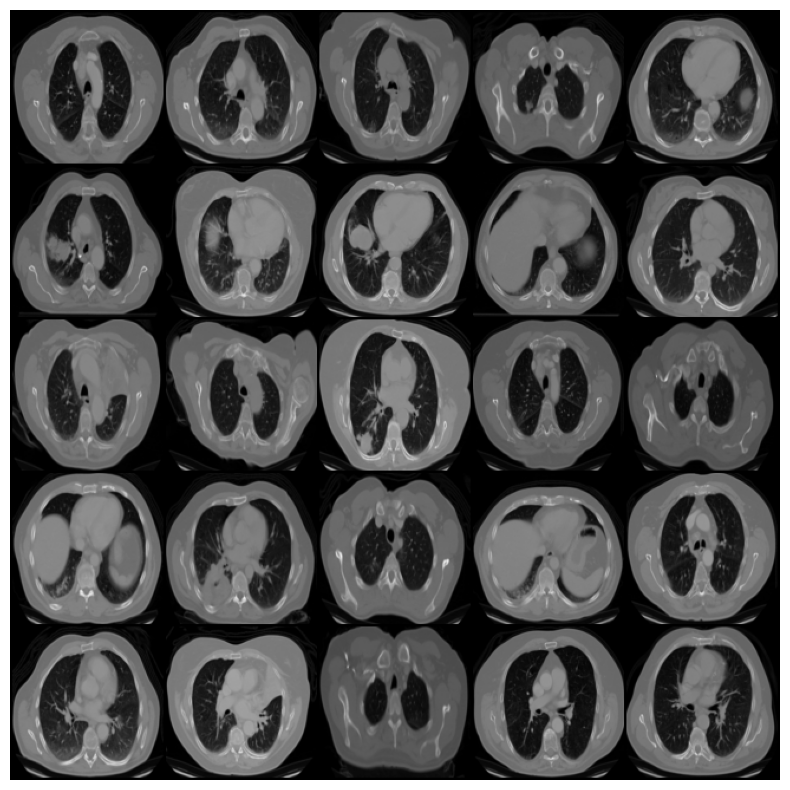

In [27]:
show_images_from_loader(dataloader=train_loader)

Se muestran a continuación las primeras $25$ imágenes del dataset de `test`:

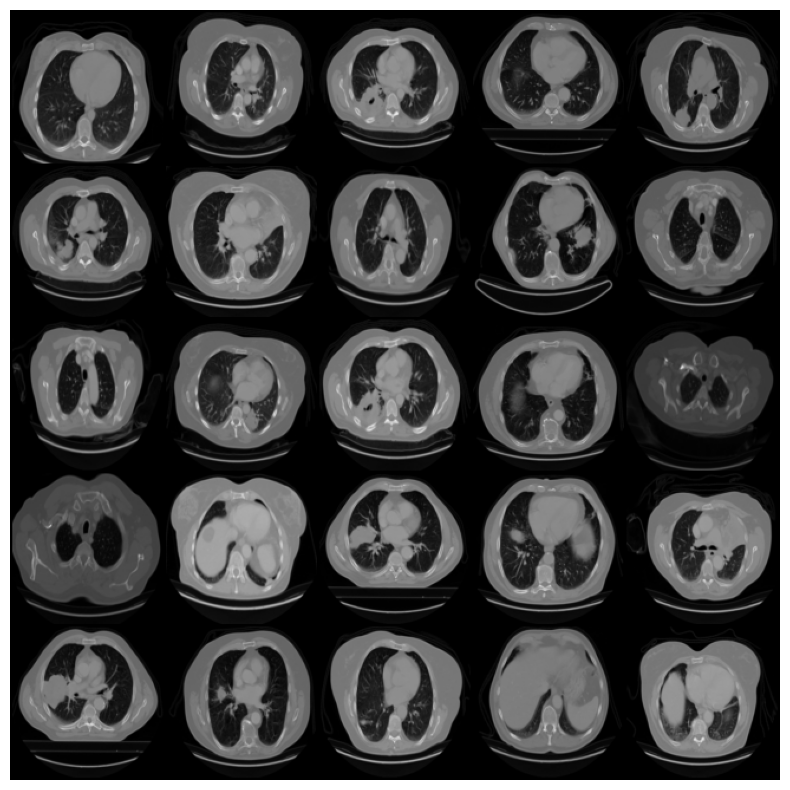

In [28]:
show_images_from_loader(dataloader=test_loader)

Se muestran a continuación las primeras $25$ imágenes del dataset de `validation`:

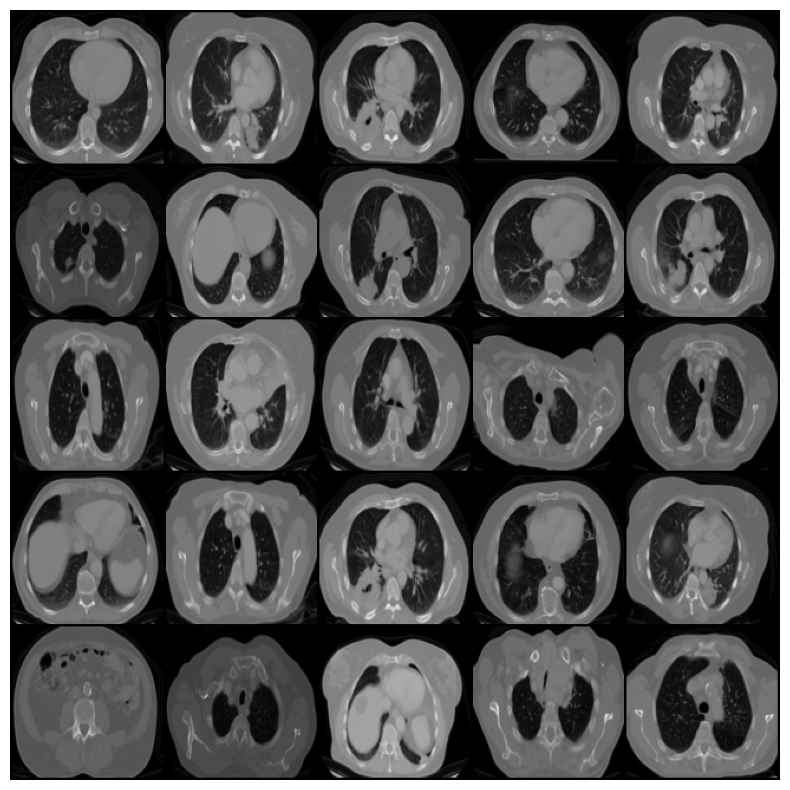

In [29]:
show_images_from_loader(dataloader=validation_loader)

***Conclusiones***

Si bien no es una conclusión final, un preprocesamiento/transformación que vale la pena estudiar es [Grayscale](https://docs.pytorch.org/vision/main/generated/torchvision.transforms.Grayscale.html), la cual convierte las imágenes en escala de grises.

Esto también beneficia que las imágenes tienen una vez procesadas `un solo canal`, lo cual facilitará los tiempos de procesamiento al entrenar los futuros modelos con los que se trabajará.

### Imágenes promedio por clases

Comenzamos recreando los dataloaders, pero en este caso con un `BATCH_SIZE` igual a $1$, a fin de procesar imagen a imagen.

In [30]:
BATCH_SIZE = 1

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE)
validation_loader = DataLoader(validation_data, batch_size=BATCH_SIZE)

Luego se crea la función `get_mean_image`, la cual, dado un dataloader y una lista de clases de imágenes dentro del mismo, devuelve la ***imagen promedio***.

Esta será util para analizar no solo como luce la imagen promedio de cada clase, sino las diferencias entre el promedio de la clase `Normal` con el resto de clases.

A partir de este análisis podremos determinar si es util aplicar ciertos preprocesamientos o no.

In [31]:
def get_mean_image(dataloader: DataLoader, channels: int = 3, height: int = 128,
                   width: int = 128,
                   labels_to_show: list = [0, 1, 2, 3]) -> np.ndarray:
  """
  Devuelve como se ve la "imagen promedio" de un dataloader.

  Args:
    dataloader (DataLoader): dataloader cuyas imágenes serán procesadas.
    channels (int): cantidad de canales que tienen las imágenes. Por defecto
      es 3.
    height (int): altura de las imágenes. Por defecto es 128.
    width (int): ancho de las imágenes. Por defecto es 128.
    labels_to_show (list): índice de los labels/clases del dataset a procesar.
  Returns:
    (np.ndarray): Imagen promedio del dataset, de la clase indicada.
  """
  mean_image_sum = torch.zeros(channels, height, width)
  num_images = 0

  for images, labels in dataloader:
      if labels in labels_to_show:
        mean_image_sum += torch.sum(images, dim=0)
        num_images += images.shape[0]

  mean_image = mean_image_sum / num_images

  if channels == 1:
    mean_image = mean_image.squeeze().numpy()

  if channels == 3:
    mean_image = mean_image.permute(1, 2, 0).numpy()
  return mean_image

Se grafica a continuación la imagen promedio de todas las clases del dataset de `train`.

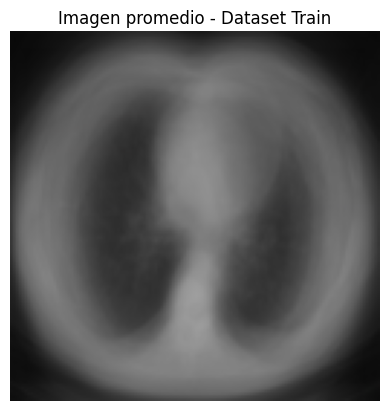

In [32]:
train_mean_all_classes = get_mean_image(dataloader=train_loader)

plt.imshow(train_mean_all_classes, vmin=0, vmax=255, cmap='Greys_r')
plt.title("Imagen promedio - Dataset Train")
plt.axis('off')
plt.show()

Se grafica a continuación la imagen promedio de la clase `adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib` del dataset de `train`.

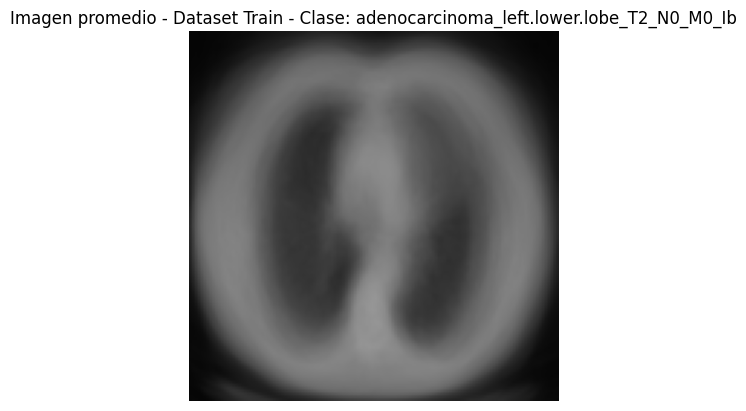

In [33]:
train_mean_0 = get_mean_image(dataloader=train_loader, labels_to_show=[0])

plt.imshow(train_mean_0, vmin=0, vmax=255, cmap='Greys_r')
plt.title(f"Imagen promedio - Dataset Train - Clase: {train_data.classes[0]}")
plt.axis('off')
plt.show()

Se grafica a continuación la imagen promedio de la clase `large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa` del dataset de `train`.

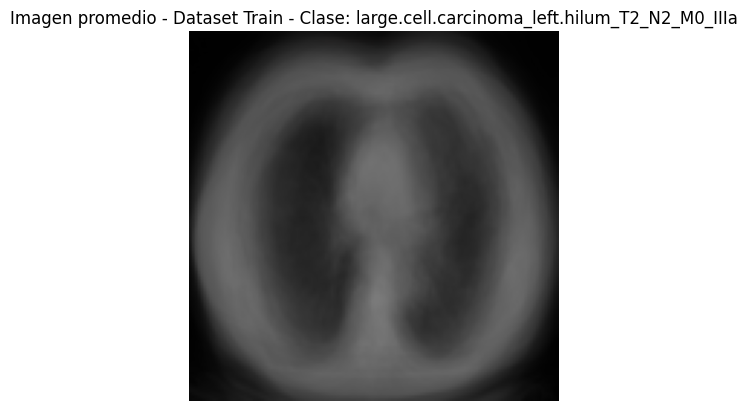

In [34]:
train_mean_1 = get_mean_image(dataloader=train_loader, labels_to_show=[1])

plt.imshow(train_mean_1, vmin=0, vmax=255, cmap='Greys_r')
plt.title(f"Imagen promedio - Dataset Train - Clase: {train_data.classes[1]}")
plt.axis('off')
plt.show()

Se grafica a continuación la imagen promedio de la clase `Normal` del dataset de `train`.

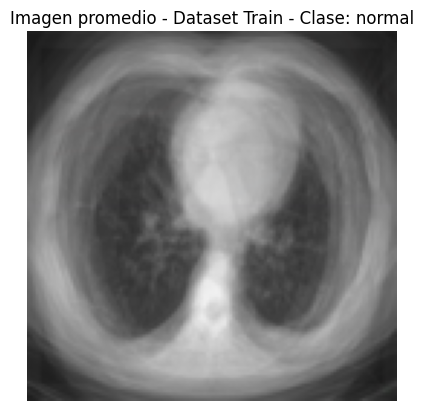

In [35]:
train_mean_2 = get_mean_image(dataloader=train_loader, labels_to_show=[2])

plt.imshow(train_mean_2, vmin=0, vmax=255, cmap='Greys_r')
plt.title(f"Imagen promedio - Dataset Train - Clase: {train_data.classes[2]}")
plt.axis('off')
plt.show()

Se grafica a continuación la imagen promedio de la clase `squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa` del dataset de `train`.

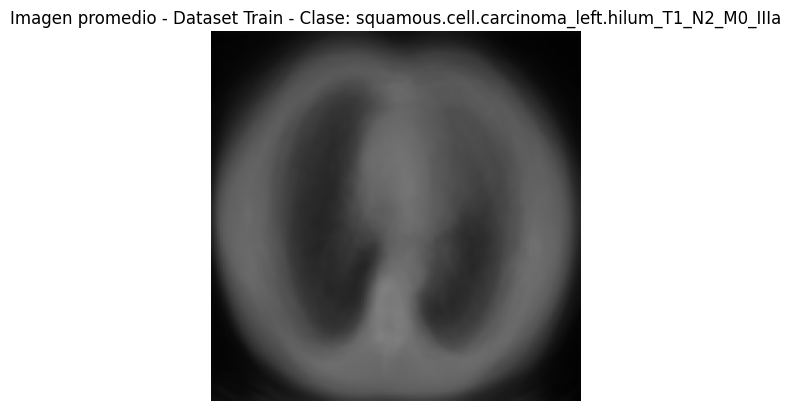

In [36]:
train_mean_3 = get_mean_image(dataloader=train_loader, labels_to_show=[3])

plt.imshow(train_mean_3, vmin=0, vmax=255, cmap='Greys_r')
plt.title(f"Imagen promedio - Dataset Train - Clase: {train_data.classes[3]}")
plt.axis('off')
plt.show()

Diferencia entre las imágenes promedio de la clase `Normal` y la clase `adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib` del dataset `train`.

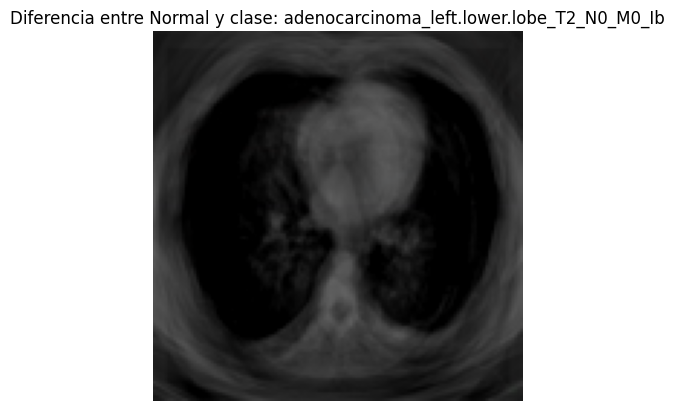

In [37]:
contrast_mean_2_0 = train_mean_2 - train_mean_0

plt.imshow(contrast_mean_2_0, cmap='bwr')
plt.title(f"Diferencia entre Normal y clase: {train_data.classes[0]}")
plt.axis('off')
plt.show()

Diferencia entre las imágenes promedio de la clase `Normal` y la clase `large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa` del dataset `train`.

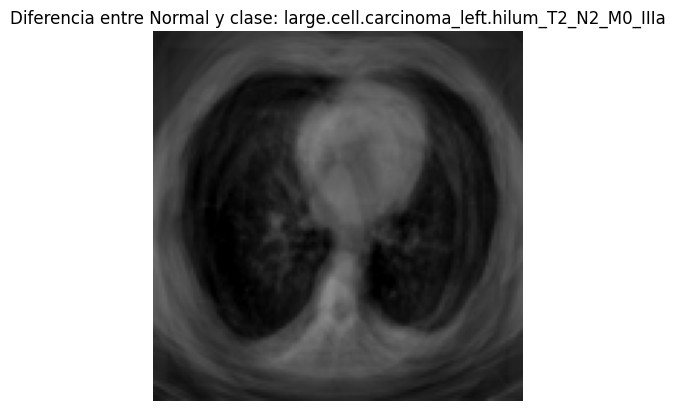

In [38]:
contrast_mean_2_1 = train_mean_2 - train_mean_1

plt.imshow(contrast_mean_2_1, cmap='bwr')
plt.title(f"Diferencia entre Normal y clase: {train_data.classes[1]}")
plt.axis('off')
plt.show()

Diferencia entre las imágenes promedio de la clase `Normal` y la clase `squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa` del dataset `train`.

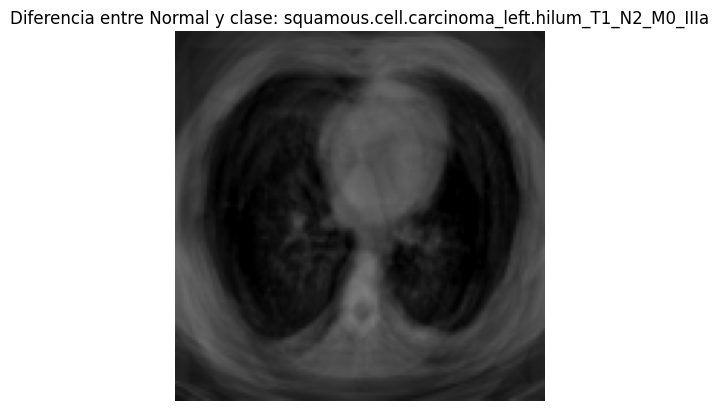

In [39]:
contrast_mean_2_3 = train_mean_2 - train_mean_3

plt.imshow(contrast_mean_2_3, cmap='bwr')
plt.title(f"Diferencia entre Normal y clase: {train_data.classes[3]}")
plt.axis('off')
plt.show()

En esta sección se hicieron dos tipos de *pruebas*:

1. Gráfico de la imagen promedio de cada clase del dataset de `train`.
1. Gráfico de la diferencia de la imagen promedio de la clase `Normal` respecto a la imagen promedio del resto de las clases, también del dataset de `train`.

La primer prueba nos permitió obtener una representación de como se ven, en promedio, las imágenes de cada clase en `train`. Si bien todas estas representaciones son importanes, la que más nos interesa es la de la clase `Normal`, ya que al no presentar *enfermedades*, si la comparamos con el resto podemos obtener algunas representaciones promedio de las mismas.

Esto último se realiza en la segunda prueba, en donde "restamos" la imagen promedio de la clase `Normal` con la imagen promedio de las demás enfermedades. Si bien a simple vista se pueden observar diferencias en las imágenes (más que nada del contraste de las mismas), el resultado obtenido no es el esperado, ya que no tenemos esas regions/zonas de interés resaltado. Aunque esto también puede deberse a nuestra falta de conocimiento dentro del área de estudio de medicina.

### PCA en imágenes

En esta sección se implementa la técnica de `PCA` en imágenes, o `Eigenfaces/Eigenimages`.

Ésta nos permitirá visualizar mejor a los componentes que mejor describen a cada clase de estudio.

Algunos de los beneficios que nos dará ésta implementación incluyen:
- Mejor visualización de los componentes que mejor describen a las clases de estudio.
- Reducción del **ruido** en las imágenes.
- Eliminar información **redundante**.

En particular, nos enfocaremos en el dataset de `train`.

Fuentes:
- [Principal Component Analysis in Medical Image Processing - A study](https://www.researchgate.net/profile/Mohammed-Abdel-Megeed-Mohammed-Salem/publication/272576742_Principal_Component_Analysis_in_Medical_Image_Processing_A_Study/links/55872e6308ae7bc2f44d31d2/Principal-Component-Analysis-in-Medical-Image-Processing-A-Study.pdf).
- [Principal Component Analysis on Computed Tomography Imaging for enhanced disease detection and diagnosis](https://www.researchgate.net/publication/388564222_Principal_Component_Analysis_on_Computed_Tomography_Imaging_for_enhanced_disease_detection_and_diagnosis#:~:text=Abstract,while%20discarding%20the%20irrelevant%20information.).
- [Exploratory Data Analysis Ideas for Image Classification](https://towardsdatascience.com/exploratory-data-analysis-ideas-for-image-classification-d3fc6bbfb2d2/).
- [PCA (Principal Components Analysis) applied to images of faces](https://medium.com/@sebastiannorena/pca-principal-components-analysis-applied-to-images-of-faces-d2fc2c083371).

In [40]:
def plot_eigenimages(dataloader: DataLoader,
                     n_components: float = 0.8,
                     title: str = "PCA - Dataloader",
                     classes_to_plot: list = [0, 1, 2, 3],
                     height: int = 128,
                     width: int = 128,
                     max_components_to_show: int = 10) -> PCA:
  """
  Función que grafica y devuelve PCA en imágenes.

  Args:
    dataloader (DataLoader): loader del set de imágenes.
    n_components (float): Porcentaje de variabilidad que se desea capturar.
      Representado con número flotante. Por defecto es 0.8.
    title (str): Título de la imagen a mostrar.
    classes_to_plot (title): Listado de clases a graficar, representados por
      su número de label.
    height (int): Altura de las imágenes. Por defecto es 128.
    width (int): Ancho de las imágenes. Por defecto es 128.
    max_components_to_show (int): Cantidad máxima de componentes a mostrar.
      Por defecto es 10.
  """
  grayscale_transform = transforms.Grayscale(num_output_channels=1)

  images_df = pd.DataFrame([])
  for image, label in dataloader:
    if label in classes_to_plot:
      image_gray = pd.Series(grayscale_transform(image).squeeze().flatten())
      images_df = pd.concat([images_df, image_gray.to_frame().T],
                            ignore_index=True)

  images_pca = PCA(n_components=n_components)
  images_pca.fit(images_df)

  nrows = math.ceil(min(len(images_pca.components_), max_components_to_show)/10)
  fig, axes = plt.subplots(nrows,10,figsize=(20,10),
    subplot_kw={"xticks":[], "yticks":[]},
    gridspec_kw=dict(hspace=0.01, wspace=0.01))
  fig.suptitle(title)

  for i, ax in enumerate(axes.flat):
    if i < images_pca.components_.shape[0]:
      ax.imshow(images_pca.components_[i].reshape(width, height),cmap="gray")
      title = f"Var: {images_pca.explained_variance_ratio_[i]*100:.4f}%"
      ax.set_title(title)
    else:
      ax.imshow(np.zeros(width * height).reshape(width, height),cmap="gray")

  return images_pca

Comenzamos graficando las componentes que capturan el $80\%$ de la variabilidad de la clase `Normal` en el dataset de `train`.

En este caso, se obtienen $8$ componentes, donde las componentes que mayor variabilidad capturan tienen el $31.85\%$ y el $19.96\%$ respectivamente.

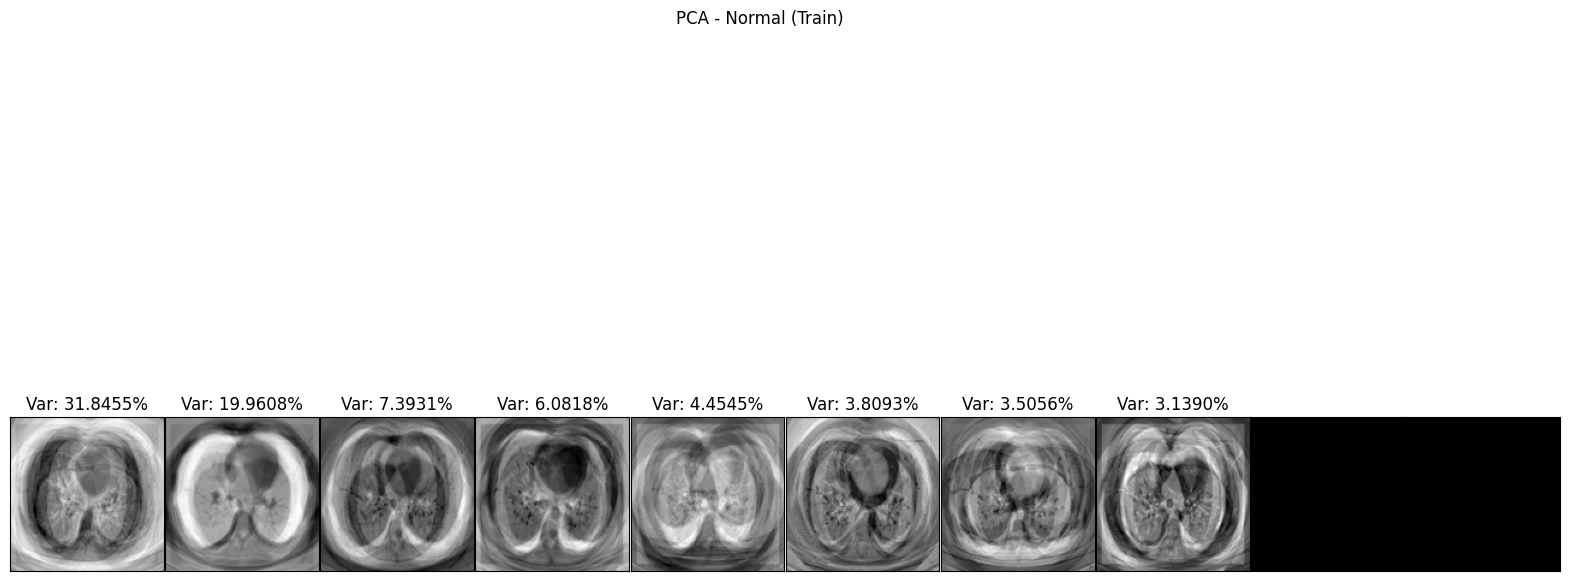

In [41]:
pca_clase_2 = plot_eigenimages(dataloader=train_loader, classes_to_plot = [2], title="PCA - Normal (Train)")

Se grafican a continuación las primeras $10$ componentes que capturan el $80\%$ de la variabilidad de la clase `Adenocarcinoma Left` (*adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib*) del dataset de `train`.

Las que mayor variabilidad capturan tienen el $32.15\%$ y el $9.69\%$ respectivamente.

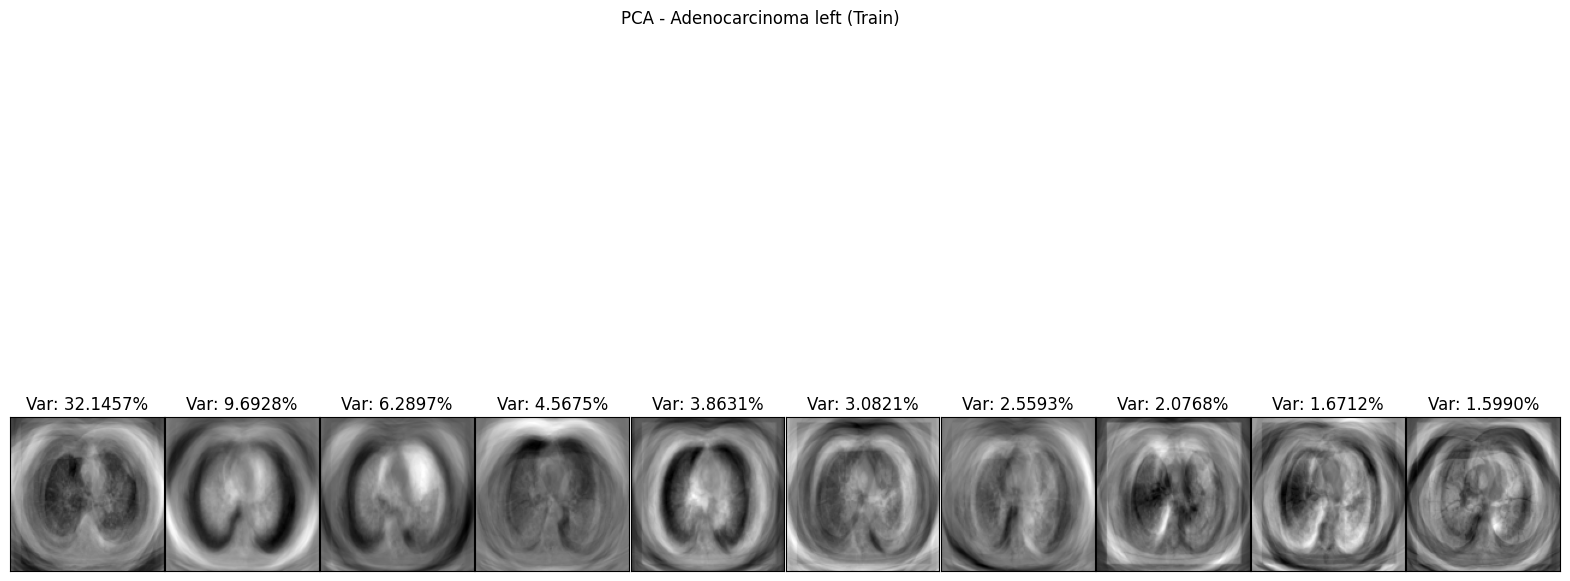

In [42]:
pca_clase_0 = plot_eigenimages(dataloader=train_loader, classes_to_plot = [0], title="PCA - Adenocarcinoma left (Train)")

Se grafican a continuación las primeras $10$ componentes que capturan el $80\%$ de la variabilidad de la clase `Large Cell Carcinoma Left` (*large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa*) del dataset de `train`.

Las que mayor variabilidad capturan tienen el $27.07\%$ y el $9.19\%$ respectivamente.

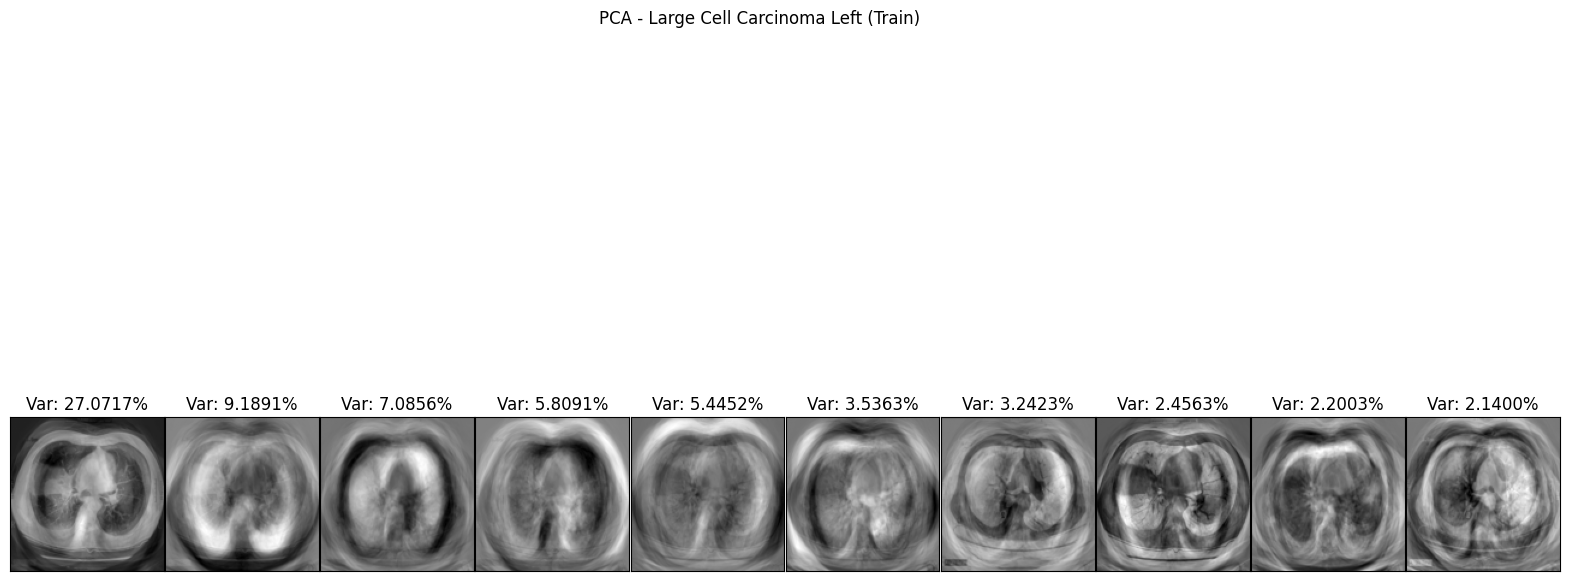

In [43]:
pca_clase_1 = plot_eigenimages(dataloader=train_loader, classes_to_plot = [1], title="PCA - Large Cell Carcinoma Left (Train)")

Finalmente se grafican las primeras $10$ componentes que capturan el $80\%$ de la variabilidad de la clase `Squamous cell carcinoma left` (*squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa*) del dataset de `train`.

Las que mayor variabilidad capturan tienen el $27.67\%$ y el $8.68\%$ respectivamente.

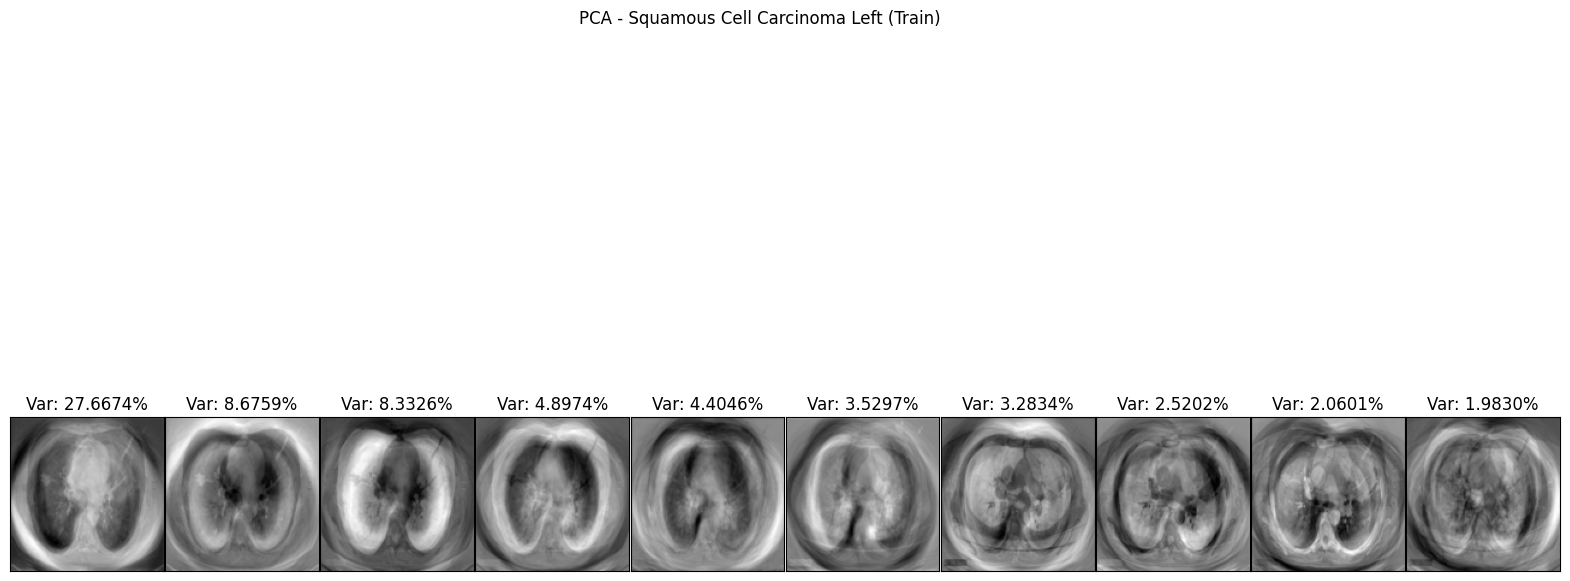

In [44]:
pca_clase_3 = plot_eigenimages(dataloader=train_loader, classes_to_plot = [3], title="PCA - Squamous Cell Carcinoma Left (Train)")

A partir de las operaciones anteriores se obtuvieron las componentes que mayor variabilidad capturan en las imágenes de cada clase.

En particular, las primeras componentes de cada clases capturan entre $27.07\%$ y $32.15\%$ de variabilidad.

Gráficamente, nos muestran una representación libre de ruido y de información redundante de las imágenes del dataset de `train`.

### Análisis de Blur (difuminado)

En esta sección se analiza el dataset de `train` a fin de determinar si las imágenes de éste están difuminadas o no (blur).

Que el dataset presente imágenes con difuminado podría ser beneficioso a la hora de entrenar un modelo de Deep Learning, ya que esto permite al modelo generalizar mejor.

Por este motivo, se comienza analizando si las imágenes tienen blur o no, mediante el uso del método laplaciano o [Varianza Laplaciana](https://www.geeksforgeeks.org/computer-vision/how-to-check-for-blurry-images-in-your-dataset-using-the-laplacian-method/). En particular, haremos uso de la función [Laplacian](https://docs.opencv.org/3.4/d5/db5/tutorial_laplace_operator.html) de `OpenCV`.

In [45]:
def get_laplacian_variance(tensor: torch.Tensor):
  """
  Dada una imagen en forma de tensor, devuelve la varianza del laplaciano.
  More info: https://www.geeksforgeeks.org/computer-vision/how-to-check-for-blurry-images-in-your-dataset-using-the-laplacian-method/
  """
  shapes = tensor.shape

  if len(shapes) > 3:
    tensor = tensor.reshape(shapes[1], shapes[2], shapes[3])

  np_img = tensor.numpy().transpose(1, 2, 0)
  np_img = (np_img * 255).astype(np.uint8)
  grayscale_image = cv2.cvtColor(np_img, cv2.COLOR_RGB2GRAY)
  laplacian_var = cv2.Laplacian(grayscale_image, cv2.CV_64F).var()

  return laplacian_var

Obtenemos los valores de varianza del laplaciano de cada imagen del dataset de `train`.

In [46]:
laplacian_variances = []
for img, lbl in train_loader:
  lp = get_laplacian_variance(img)
  laplacian_variances.append(lp)

Graficamos los valores obtenidos en un histograma, utilizando $10$ bins.

Se observa que la mayoría de las imágenes se encuentran en los tres primeros bins, definidos por los siguientes rangos:

1. Bin 1 -> [$140.149$, $450.221$] -> $145$ imágenes.
1. Bin 2 -> [$450.221$, $760.294$] -> $224$ imágenes.
1. Bin 3 -> [$760.294$, $1070.366$] -> $78$ imágenes

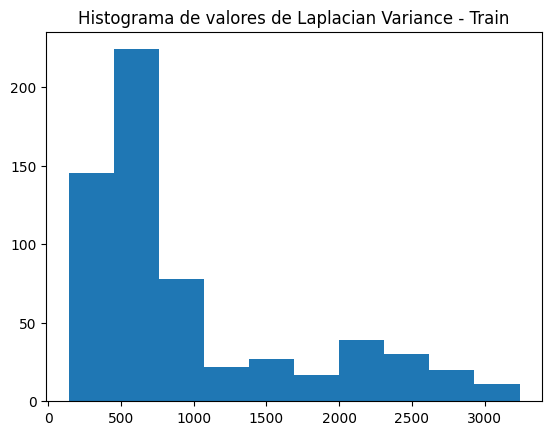

In [47]:
n, bins, patches = plt.hist(laplacian_variances, bins=10)
plt.title("Histograma de valores de Laplacian Variance - Train")
plt.show()

Cantidad de imágenes por bins:

In [48]:
n

array([145., 224.,  78.,  22.,  27.,  17.,  39.,  30.,  20.,  11.])

Rango de bins:

In [49]:
bins

array([ 140.14899349,  450.22127012,  760.29354675, 1070.36582337,
       1380.4381    , 1690.51037662, 2000.58265325, 2310.65492988,
       2620.7272065 , 2930.79948313, 3240.87175976])

A fin de determinar un `threshold` o límite de `laplacian variance` para determinar si una imagen está o no borrosa, vamos a analizar imágenes de los dos primeros bins, a fin de si estas están borrosas o no.

**NOTA**: un valor relativamente bajo del `laplacian variance` indica que la imagen está borrosa.

En caso de no encontrar casos positivos (imágenes borrosas), podemos decir que el dataset (o por lo menos la mayoría de las imágenes en `train`) NO están borrosas. Además, no será necesario analizar el resto de los bins, ya que los valores del laplaciano son mayores.

En caso de SI encontrar casos positivos en el primer bin, pero NO en el segundo, definiremos nuestro límite en función de los propios límites de cada bin.

En caso de SI encontrar casos positivos en ambos bins, deberemos agregar el tercer bin al análisis; y así sucesivamente con el resto de los bins.

In [50]:
bin_1_imgs = []
bin_2_imgs = []

laplacian_variances = []
for img, lbl in train_loader:
  lp = get_laplacian_variance(img)

  if lp <= 140.14899349:
    bin_1_imgs.append(img)

  if lp > 140.14899349 and lp <= 450.22127012:
    bin_1_imgs.append(img)

  if lp > 450.22127012 and lp <= 760.29354675:
    bin_2_imgs.append(img)

In [51]:
# Validamos que la cantidad de elementos en cada array corresponda a la cantidad de elementos por bin
len_b1 = len(bin_1_imgs)
len_b2 = len(bin_2_imgs)

print(f"Cantidad de elementos en el primer bin: {len_b1}")
print(f"Cantidad de elementos en el segundo bin: {len_b2}")

Cantidad de elementos en el primer bin: 145
Cantidad de elementos en el segundo bin: 224


In [52]:
def print_n_images_from_array(img_list: list, num_images: int = 5,
                              width: int = 128, height: int = 128,
                              channels: int = 3, title: str = "Imgs"):
  """
  Imprime N imágenes de un array de tensores que representan imágenes.

  Args:
    img_list (list): Lista de imágenes, representadas por tensores.
    num_images (int): Cantidad de imágenes a mostrar en una sola fila.
      Por defecto es 5.
    width (int): Ancho de la imagen. Por defecto es 128.
    height (int): Alto de la imagen. Por defecto es 128.
    channels (int): Cantidad de canales en la imagen. Por defecto es 3.
    title (str): Título del gráfico.
  """
  fig, axes = plt.subplots(nrows=1, ncols=num_images, figsize=(15, 3))
  fig.suptitle(title)
  len_ = len(img_list)
  for i in range(num_images):
    idx = random.randint(0, len_ - 1)
    axes[i].imshow(img_list[idx].reshape(channels, width, height).numpy().transpose(1, 2, 0))
    axes[i].axis('off')

#### Se muestran a continuación $5$ imágenes elegidas ***al azar*** correspondientes al Bin 1 y al Bin 2.

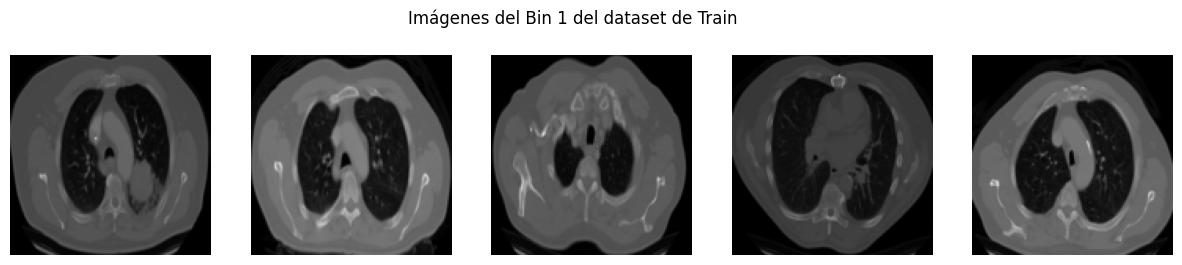

In [53]:
print_n_images_from_array(img_list=bin_1_imgs, title="Imágenes del Bin 1 del dataset de Train")

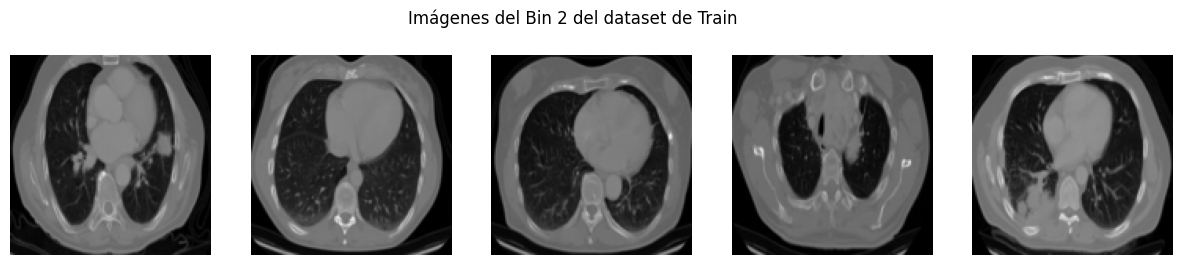

In [54]:
print_n_images_from_array(img_list=bin_2_imgs, title="Imágenes del Bin 2 del dataset de Train")

Tanto en las imágenes del Bin 1 y Bin 2 del dataset de NO se observan casos *difuminados* o *con blur*.

Si bien a la hora de utilizar imágenes de dataset se busca que estas no tengan errores o problemas de ruido, a la hora de ***entrenar modelos*** podría llegar ser beneficioso que estas tengan cierto *blur*, a fin de permitir que el modelo *generalice* mejor y de esta manera se evite el ***overfitting***.

Por esto último, podría ser beneficioso aplicar técnicas como desenfoque gaussiano o *Gaussian Blur* en el dataset mediante la transformación [GaussianBlur](https://docs.pytorch.org/vision/main/generated/torchvision.transforms.GaussianBlur.html).

### Cálculo de Media y Desviación Estándar para Normalización

Antes de definir las transformaciones finales y el pipeline de aumentación de datos, es una práctica fundamental calcular los estadísticos del conjunto de entrenamiento. Específicamente, necesitamos la media y la desviación estándar por canal.

Estos valores se utilizarán para la normalización de las imágenes. La normalización (restar la media y dividir por la desviación estándar) asegura que los datos de entrada al modelo tengan una distribución centrada en cero y con varianza unitaria, lo cual es crítico para la estabilidad del entrenamiento y la velocidad de convergencia de redes profundas (como las vistas en la "Clase 2", ej. ResNet, VGG19).

Para este cálculo, se utiliza el train_data (con basic_transform que ya aplica ToTensor()) y se itera sobre él.

In [55]:
# Para el cálculo de estadísticos, es preferible no mezclar los datos (shuffle=False)
# Se utiliza el train_data que ya definimos con ToTensor()
train_loader_for_stats = DataLoader(train_data, batch_size=64, shuffle=False)

def get_mean_std(loader):
    """
    Calcula la media y la desviación estándar por canal (RGB) de un
    conjunto de datos cargado por un DataLoader.
    """
    # Inicialización de variables
    channels_sum, channels_sqrd_sum, num_batches = 0, 0, 0

    print("Calculando media y std del dataset de train...")
    for data, _ in loader:
        # data tiene shape [batch_size, channels, height, width]
        # Se calcula la media y la media de los cuadrados por canal (dim 1)
        # sobre las dimensiones espaciales (dim 2, 3) y el batch (dim 0)
        channels_sum += torch.mean(data, dim=[0, 2, 3])
        channels_sqrd_sum += torch.mean(data**2, dim=[0, 2, 3])
        num_batches += 1

    # Media final
    mean = channels_sum / num_batches

    # Varianza = E[X^2] - (E[X])^2
    # Std = sqrt(Varianza)
    std = (channels_sqrd_sum / num_batches - mean**2)**0.5

    return mean, std

# Ejecutamos el cálculo
dataset_mean, dataset_std = get_mean_std(train_loader_for_stats)

print(f"\nCálculo finalizado.")
print(f"Media del dataset (por canal): {dataset_mean}")
print(f"Desviación Estándar del dataset (por canal): {dataset_std}")

Calculando media y std del dataset de train...

Cálculo finalizado.
Media del dataset (por canal): tensor([0.3218, 0.3218, 0.3218])
Desviación Estándar del dataset (por canal): tensor([0.2606, 0.2606, 0.2606])


Con los tensores dataset_mean y dataset_std calculados, ahora poseemos los estadísticos específicos de nuestro dataset de entrenamiento

### Definición de Transformaciones y Data Augmentation

Continuando con las observaciones del análisis exploratorio, se identificaron dos puntos clave:

1. La variabilidad de dimensiones en las imágenes (ej. alto de 168 a 1200 en train), lo que hace mandatorio un redimensionamiento (Resize).

2. La presencia de imágenes con blur, lo que sugiere que aplicar un desenfoque (como el desenfoque gaussiano) de forma aleatoria podría ser beneficioso para que el modelo generalice mejor y se evite el overfitting.

Procedemos a implementar un pipeline de transformaciones que aborde estos puntos:

In [56]:
# --- Definición de Transformaciones ---

# Para los conjuntos de validación y test, las transformaciones son
# determinísticas: solo se busca estandarizar la entrada.
val_test_transform = transforms.Compose([
    # 1. Redimensionamiento: Mandatorio. Como se vio en el EDA, las
    # imágenes tienen tamaños variables y las CNNs requieren una entrada fija.
    # Se usa 224x224, estándar para arquitecturas pre-entrenadas (ej. ResNet).
    transforms.Resize((224, 224)),

    # 2. Conversión a Tensor: Convierte la imagen PIL a un Tensor de PyTorch
    # y escala los valores de píxeles al rango [0, 1].
    transforms.ToTensor(),

    # 3. Normalización: Se utilizan la media y std calculadas del dataset de 'train'.
    # Esto centra los datos (media 0, std 1), crucial para la estabilidad
    # y velocidad de convergencia del entrenamiento.
    transforms.Normalize(mean=dataset_mean, std=dataset_std)
])

# Para el conjunto de entrenamiento, se aplica Data Augmentation
# para mejorar la generalización y reducir el overfitting (visto en Clase 1).
train_transform = transforms.Compose([
    # 1. Redimensionamiento: Idéntico a 'val_test_transform' para consistencia.
    transforms.Resize((224, 224)),

    # 2. Augmentation: Desenfoque Gaussiano (Hipótesis del EDA)
    # Se aplica aleatoriamente (p=0.5) para simular el 'blur' detectado
    # en el análisis, forzando al modelo a ser robusto a esta característica.
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 5.0))
    ], p=0.5),

    # 3. Augmentation: Giro Horizontal
    # Introduce invarianza a la orientación. Se asume que la clase
    # no depende de la orientación horizontal (izq/der). Es una
    # aumentación de bajo costo y alta efectividad.
    transforms.RandomHorizontalFlip(p=0.5),

    # 4. Augmentation: Rotación Leve
    # Simula pequeñas variaciones en el ángulo de la toma (cámara inclinada).
    # Ayuda al modelo a no depender de la alineación perfecta.
    transforms.RandomRotation(15),

    # 5. Conversión a Tensor: (ver justificación en val_test_transform)
    transforms.ToTensor(),

    # 6. Normalización: (ver justificación en val_test_transform)
    transforms.Normalize(mean=dataset_mean, std=dataset_std)
])

# Se recargan los datasets utilizando estas nuevas transformaciones
train_data_aug = datasets.ImageFolder(root=DATASET_TRAIN, transform=train_transform)
validation_data_aug = datasets.ImageFolder(root=DATASET_VALID, transform=val_test_transform)

print("Datasets recargados con 'train_transform' (con augmentation) y 'val_test_transform'.")

Datasets recargados con 'train_transform' (con augmentation) y 'val_test_transform'.


### Visualización del Efecto de Augmentation

Finalmente, para validar visualmente que las transformaciones de Data Augmentation se están aplicando como se espera (especialmente el GaussianBlur aleatorio), se tomará una imagen del dataset de train y se le aplicará la transformación train_transform múltiples veces.

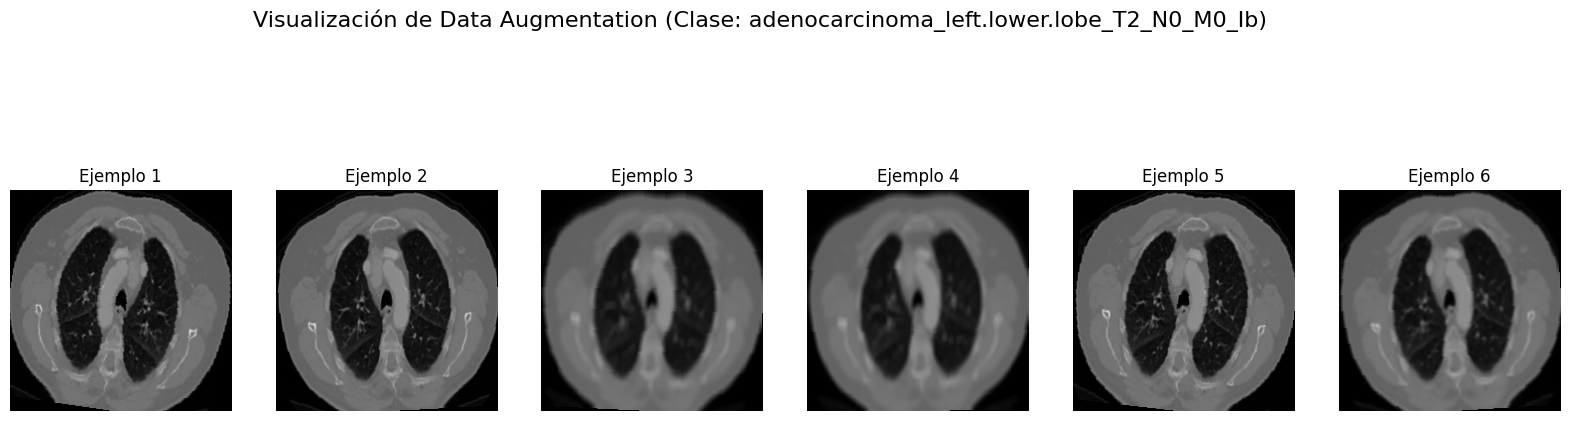

In [57]:
def show_augmentations_preview(dataset: ImageFolder, num_images: int = 6):
    """
    Muestra una imagen del dataset con 'num_images' transformaciones
    aleatorias aplicadas. Incluye la des-normalización para poder
    visualizar correctamente con matplotlib.
    """
    fig, axes = plt.subplots(1, num_images, figsize=(20, 6))

    # Tomamos la primera imagen como ejemplo
    img_path, label = dataset.samples[0]

    # Se necesita invertir la normalización para visualización
    mean = np.array(dataset_mean)
    std = np.array(dataset_std)

    for i in range(num_images):
        # Al hacer __getitem__, ImageFolder aplica el 'transform'
        aug_img_tensor, _ = dataset[0]

        # Invertir Normalización y ToTensor
        # (C, H, W) -> (H, W, C)
        aug_img = aug_img_tensor.permute(1, 2, 0).numpy()
        aug_img = std * aug_img + mean # Des-normalizar
        aug_img = np.clip(aug_img, 0, 1) # Asegurar rango [0, 1]

        axes[i].imshow(aug_img)
        axes[i].set_title(f"Ejemplo {i+1}")
        axes[i].axis('off')

    plt.suptitle(f"Visualización de Data Augmentation (Clase: {dataset.classes[label]})", fontsize=16)
    plt.show()

# Visualizamos 6 ejemplos de aumentación sobre la primera imagen de train
show_augmentations_preview(train_data_aug, num_images=6)

Como se observa en la visualización, las transformaciones se aplican correctamente. Cada imagen es una versión diferente de la original, presentando rotaciones, giros y, notablemente, en algunas de ellas se aplica el desenfoque gaussiano (como se definió con p=0.5).

## Baseline ResNet18

### Data Augmentation

Comenzamos aplicando el `data augmentation` definido en el paso anterior (`EDA - Definición de Transformaciones y Data Augmentation`).

In [58]:
train_data = datasets.ImageFolder(root=DATASET_TRAIN, transform=train_transform)
validation_data = datasets.ImageFolder(root=DATASET_VALID, transform=val_test_transform)
test_data = datasets.ImageFolder(root=DATASET_TEST, transform=val_test_transform)

Se crean a continuación los dataloaders de `train`, `test` y `validation`, utilizando un ***Batch Size*** de $32$. El único data loader con `shuffle = True` es el de `train`.

In [59]:
BATCH_SIZE = 32

In [60]:
train_loader = DataLoader(dataset=train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(dataset=test_data, batch_size=BATCH_SIZE, shuffle=False)
validation_loader = DataLoader(dataset=validation_data, batch_size=BATCH_SIZE, shuffle=False)

### Imports

In [61]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 15.1 MB/s eta 0:00:00


In [62]:
from torchvision.models import resnet18, ResNet18_Weights
import torchsummary
import torchmetrics
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

### Función para train-test loop

A continuación, se define el *loop* principal de entrenamiento. Este proceso iterará sobre el número de `EPOCHS` definido.

En cada época, se realizan dos fases:

1.  **Fase de Entrenamiento (`model.train()`):**
    * Se itera sobre el `train_loader`.
    * Se realiza el *forward pass* (propagación hacia adelante).
    * Se calcula la pérdida (***Loss***) comparando las predicciones con las etiquetas reales (usando `criterion`).
    * Se realiza el *backward pass* (retropropagación) y se actualizan los pesos del modelo (`optimizer.step()`).
    * Se acumulan la *loss* y las métricas de esta fase.

2.  **Fase de Validación (`model.eval()`):**
    * Se desactiva el cálculo de gradientes (`with torch.no_grad()`) para ahorrar cómputo, ya que en esta fase no se aprende.
    * Se itera sobre el `validation_loader`.
    * Se evalúa el rendimiento del modelo sobre datos "no vistos" (el conjunto de validación).
    * Se acumulan la *loss* y las métricas de validación.

Además, se implementará un mecanismo de **Early Stopping**. Este monitoreará la pérdida de validación (`val_loss`) y detendrá el entrenamiento si esta no mejora después de un número determinado de épocas (`patience`), evitando así el *overfitting* y ahorrando tiempo de cómputo.

Se almacenará el historial de *loss* y métricas de ambas fases en cada época para su posterior visualización.

In [63]:
def train_eval_loop(model: any, optimizer, criterion, metric,
                    data: dict, epochs: int = 100, tb_writer: dict = None):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    train_loader = data["train"]
    valid_loader = data["valid"]

    if tb_writer:
        train_writer = tb_writer["train"]
        valid_writer = tb_writer["valid"]

        train_writer.add_graph(model, torch.zeros((1, data["image_channels"],
                                                     data["image_width"],
                                                     data["image_height"])))
        valid_writer.add_graph(model, torch.zeros((1, data["image_channels"],
                                                     data["image_width"],
                                                     data["image_height"])))
    model.to(device)
    metric.to(device)

    train_loss = []
    train_metric = []
    valid_loss = []
    valid_metric = []

    patience = 5  # Número de épocas de paciencia antes de detenerse
    best_val_loss = float('inf') # Se busca minimizar la loss de validación
    epochs_no_improve = 0
    # ----------------------------------------

    # (La variable 'history' se crea al final, con los resultados)

    # Corregido: Usar 'epochs' (argumento) en lugar de 'EPOCHS' (indefinido)
    print(f"Iniciando entrenamiento por {epochs} épocas...")
    print(f"Early Stopping activado con paciencia de {patience} épocas.")

    for epoch in range(epochs):

        ####################  TRAIN  ####################
        model.train()

        epoch_train_loss = 0.0
        epoch_train_metric = 0.0

        for train_data, train_target in train_loader:

            train_data = train_data.to(device)
            train_target = train_target.to(device)

            optimizer.zero_grad()
            output = model(train_data.float())
            loss = criterion(output, train_target)
            epoch_train_loss += loss.item()
            loss.backward()
            optimizer.step()

            epoch_train_metric += metric(output, train_target).item()

        epoch_train_loss = epoch_train_loss / len(train_loader)
        epoch_train_metric = epoch_train_metric / len(train_loader)
        train_loss.append(epoch_train_loss)
        train_metric.append(epoch_train_metric)

        ####################  EVAL  ####################
        model.eval()

        epoch_valid_loss = 0.0
        epoch_valid_metric = 0.0

        all_preds = torch.tensor([]).to(device)
        all_labels = torch.tensor([]).to(device)

        # Desactivamos gradientes para la validación
        with torch.no_grad():
            for valid_data, valid_target in valid_loader:
                valid_data = valid_data.to(device)
                valid_target = valid_target.to(device)

                output = model(valid_data.float())
                epoch_valid_loss += criterion(output, valid_target).item()
                epoch_valid_metric += metric(output, valid_target).item()

                all_preds = torch.cat((all_preds, output))
                all_labels = torch.cat((all_labels, valid_target))

        epoch_valid_loss = epoch_valid_loss / len(valid_loader)
        epoch_valid_metric = epoch_valid_metric / len(valid_loader)
        valid_loss.append(epoch_valid_loss)
        valid_metric.append(epoch_valid_metric)

        print("Epoch: {}/{} - Train loss {:.6f} - Train Metric {:.6f} - Valid Loss {:.6f} - Valid Metric {:.6f}".format(
        epoch+1, epochs, epoch_train_loss, epoch_train_metric, epoch_valid_loss, epoch_valid_metric))

        if tb_writer:
            train_writer.add_scalar("loss", epoch_train_loss, epoch)
            valid_writer.add_scalar("loss", epoch_valid_loss, epoch)
            train_writer.add_scalar("metric", epoch_train_metric, epoch)
            valid_writer.add_scalar("metric", epoch_valid_metric, epoch)
            train_writer.flush()
            valid_writer.flush()

        # --- Lógica de Early Stopping ---
        if epoch_valid_loss < best_val_loss:
            print(f"    Mejora en Val Loss: ({best_val_loss:.4f} --> {epoch_valid_loss:.4f}). Guardando modelo...")
            best_val_loss = epoch_valid_loss
            epochs_no_improve = 0
            # Opcional: guardar el mejor modelo
            # torch.save(model.state_dict(), 'best_model.pth')
        else:
            epochs_no_improve += 1
            print(f"    No hay mejora en Val Loss por {epochs_no_improve} épocas.")

        if epochs_no_improve == patience:
            print(f"\n¡EARLY STOPPING! No hubo mejora en {patience} épocas. Deteniendo entrenamiento en epoch {epoch+1}.")
            break  # Se rompe el loop 'for epoch...'
        # ----------------------------------

    # Se arma el diccionario 'history' al final, con los resultados
    history = {}
    history["train_loss"] = train_loss
    history["train_metric"] = train_metric
    history["valid_loss"] = valid_loss
    history["valid_metric"] = valid_metric
    history["labels_last_epoch"] = all_labels
    history["pred_last_epoch"] = all_preds

    return history

### Modelo para baseline

Para este *baseline*, se utilizará la técnica de **Transfer Learning**

**¿Por qué Transfer Learning?**
Dado el tamaño limitado de nuestro dataset de *train* (613 imágenes), entrenar un modelo desde cero (con pesos aleatorios) conllevaría un alto riesgo de ***overfitting***.

Al usar Transfer Learning, inicializamos el modelo con pesos pre-entrenados en un dataset masivo (ImageNet). Esto nos da un "extractor de características" robusto, permitiendo una convergencia más rápida y una mejor *generalización*.

**¿Por qué ResNet18?**
Se optó por **ResNet18** por su excelente balance entre rendimiento y costo computacional. Es una arquitectura profunda (gracias a las *skip connections*) pero lo suficientemente ligera para entrenar rápido y no "memorizar" (hacer *overfit*) nuestro dataset pequeño, a diferencia de modelos más pesados como ResNet101.

In [64]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_CHANNELS = 3
OUTPUTS = 4
CANT_CLASES = 4

In [65]:
from torchvision.models import resnet18, ResNet18_Weights

# Se cargan los pesos 'IMAGENET1K_V1'. Estos son los pesos finales y
# optimizados que la red aprendió tras ser entrenada en el dataset
# ImageNet (1000 clases). Este es el "conocimiento" que vamos a transferir.
weights = ResNet18_Weights.IMAGENET1K_V1

# Se inicializa el modelo ResNet18 con los pesos pre-entrenados.
resnet18_model = resnet18(weights=weights)

#  Los modelos pre-entrenados esperan exactamente el mismo pre-procesamiento con el que fueron entrenados.
# 'weights.transforms()' es una utilidad que contiene las transformaciones
# de ImageNet:
# - Resize(224)
# - ToTensor()
# - Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
# Si usáramos nuestras propias transformaciones (con nuestra media/std),
# la distribución de entrada sería incorrecta y el rendimiento colapsaría.
# Para este baseline, se prioriza la consistencia con los pesos.

transforms = weights.transforms()

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 148MB/s]


In [66]:
transforms

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [67]:
train_transform

Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomApply(
    p=0.5
    GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 5.0))
)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ToTensor()
    Normalize(mean=tensor([0.3218, 0.3218, 0.3218]), std=tensor([0.2606, 0.2606, 0.2606]))
)

In [68]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

resnet18_model.to(device)

torchsummary.summary(resnet18_model, input_size=(IMG_CHANNELS, IMG_HEIGHT, IMG_WIDTH))
resnet18_model.modules

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,864
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
       BasicBlock-11           [-1, 64, 56, 56]               0
           Conv2d-12           [-1, 64, 56, 56]          36,864
      BatchNorm2d-13           [-1, 64, 56, 56]             128
             ReLU-14           [-1, 64,

<bound method Module.modules of ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (layer2): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (downsample): Sequential(
        (0): Conv2d(64, 128, kernel_size=(1, 1), stride=(2, 2), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (1): BasicBlock(
      (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (layer3): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (downsample): Sequential(
        (0): Conv2d(128, 256, kernel_size=(1, 1), stride=(2, 2), bias=False)
        (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (1): BasicBlock(
      (conv1): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (layer4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(256, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (downsample): Sequential(
        (0): Conv2d(256, 512, kernel_size=(1, 1), stride=(

In [69]:
# Estamos haciendo Transfer Learning en modo "Feature Extraction".
# No queremos que el 'backward pass' (cálculo de gradientes) modifique
# los pesos del extractor de características (las capas convolucionales)
# que ya "saben" detectar bordes, texturas, etc., gracias a ImageNet.
#
# Al poner 'requires_grad = False', le decimos a PyTorch que no calcule
# gradientes para estos parámetros durante el entrenamiento. Solo se
# entrenará la capa que definamos a continuación.
for param in resnet18_model.parameters():
    param.requires_grad = False

# La arquitectura ResNet18 termina en una capa 'Fully Connected' (fc)
# que, en el modelo original, clasificaba las 1000 clases de ImageNet.
# Debemos reemplazarla por una nueva capa que se ajuste a nuestro problema.

# 'resnet18_model.fc.in_features' lee automáticamente el número de "entradas"
# que la última capa convolucional entrega a la capa 'fc'.
# En ResNet18, esto es 512.
last_layer_in_features = resnet18_model.fc.in_features

resnet18_model.fc = torch.nn.Linear(in_features=last_layer_in_features, out_features=OUTPUTS)

In [70]:
last_layer_in_features

512

### Entrenamiento

La elección de la función de pérdida es crítica y depende de la naturaleza del problema.

Se utiliza **`nn.CrossEntropyLoss`** (Pérdida de Entropía Cruzada) porque es el estándar de la industria y la opción matemáticamente más adecuada para problemas de **clasificación multi-clase** (cuando N > 2).

* En nuestro caso, tenemos **4 clases de salida** (según se definió en la capa `model.fc`).
* Esta función de pérdida es ideal porque asume que las clases son **mutuamente excluyentes** (una imagen pertenece a una sola clase, no a varias).
* Internamente, `nn.CrossEntropyLoss` en PyTorch combina dos pasos: `LogSoftmax` y `NLLLoss`, midiendo qué tan "equivocadas" están las predicciones del modelo.

In [71]:
# Se define la función de pérdida (Loss)
criterion = torch.nn.CrossEntropyLoss()

La elección de la métrica de evaluación define qué consideramos un "buen" modelo. Mientras la *Loss Function* (`CrossEntropy`) se usa para *optimizar* la red (minimizar el error de gradiente), la métrica de negocio nos dice si el modelo es *útil*.

Para este problema, asumimos que el costo de los **Falsos Negativos (FN)** es mucho mayor que el de los **Falsos Positivos (FP)**.

* **Falso Negativo (FN):** El modelo predice "NO" (o "Bin 1", "Bin 2") cuando la realidad es "SI". Este es el peor error; es *omitir* un caso positivo.
* **Falso Positivo (FP):** El modelo predice "SI" cuando la realidad es "NO". Este error es menos costoso, ya que podría ser filtrado en una revisión posterior.

La métrica que se enfoca explícitamente en **minimizar los Falsos Negativos** es el **Recall**.

$$\text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}}$$

El Recall responde a la pregunta: *De todos los casos que realmente eran positivos ("SI"), ¿qué porcentaje logramos identificar correctamente?*

Por lo tanto, **maximizaremos el Recall**, aceptando un posible detrimento en la *Precisión* (que mide los Falsos Positivos).

In [72]:
metric = torchmetrics.Recall(task='multiclass', num_classes=CANT_CLASES)

Se utiliza **`torch.optim.Adam`** (Adaptive Moment Estimation) porque es considerado uno de los optimizadores más robustos y efectivos. Combina las ventajas de **Momentum** (acelerar la convergencia) y **RMSprop** (learning rates adaptativos por parámetro). Generalmente converge más rápido que `SGD` y es una excelente opción de *baseline*.

El uso de un `LEARNING_RATE` bajo es una decisión intencional y crucial en el **Transfer Learning**:
* **Ajuste Fino (Fine-Tuning)**: No estamos entrenando desde cero. Los pesos de ResNet18 ya están altamente optimizados por ImageNet.
* **Riesgo de "Olvido Catastrófico"**: Un LR alto (ej. `1e-2`) "destruiría" la información valiosa aprendida de ImageNet al desestabilizar los pesos.
* **Ajuste Preciso**: Un LR bajo asegura que solo hagamos "pequeños retoques". Estamos entrenando *solamente* la nueva capa `fc`, por lo que queremos que aprenda a "conectar" las características pre-entrenadas con nuestras clases sin perturbar el resto.

Aunque `1e-4` es un punto de partida seguro, el siguiente paso en la experimentación  sería probar un rango de valores (ej. `1e-3`, `5e-5`) en un proceso de **Hyperparameter Tuning**.

In [73]:
# Se define un learning rate bajo.
LEARNING_RATE = 1e-4

# Se instancia el optimizador Adam.
# IMPORTANTE: Pasamos 'model.fc.parameters()'.
# Esto le dice a Adam que SOLAMENTE optimice los parámetros
# de nuestra nueva capa 'fc', ya que el resto está congelado.
optimizer = torch.optim.Adam(resnet18_model.fc.parameters(), lr=LEARNING_RATE)

In [74]:
data = {"train": train_loader, "valid": test_loader, "image_width": IMG_WIDTH, "image_height": IMG_HEIGHT}

In [75]:
# Se define el número de épocas. Como se trabaja con Early Stopping,
# no es problemático setear un número alto (ej. 50),
# ya que el loop se detendrá si el modelo deja de mejorar.
EPOCHS = 50

# Se ejecuta el entrenamiento
history = train_eval_loop(resnet18_model, optimizer, criterion, metric,
                          data=data, epochs=EPOCHS, tb_writer=None)

Iniciando entrenamiento por 50 épocas...
Early Stopping activado con paciencia de 5 épocas.
Epoch: 1/50 - Train loss 1.459638 - Train Metric 0.253750 - Valid Loss 1.446021 - Valid Metric 0.415625
    Mejora en Val Loss: (inf --> 1.4460). Guardando modelo...
Epoch: 2/50 - Train loss 1.353328 - Train Metric 0.314375 - Valid Loss 1.373521 - Valid Metric 0.406250
    Mejora en Val Loss: (1.4460 --> 1.3735). Guardando modelo...
Epoch: 3/50 - Train loss 1.332830 - Train Metric 0.340938 - Valid Loss 1.274068 - Valid Metric 0.406250
    Mejora en Val Loss: (1.3735 --> 1.2741). Guardando modelo...
Epoch: 4/50 - Train loss 1.304869 - Train Metric 0.353438 - Valid Loss 1.228978 - Valid Metric 0.394907
    Mejora en Val Loss: (1.2741 --> 1.2290). Guardando modelo...
Epoch: 5/50 - Train loss 1.303399 - Train Metric 0.374063 - Valid Loss 1.213146 - Valid Metric 0.426505
    Mejora en Val Loss: (1.2290 --> 1.2131). Guardando modelo...
Epoch: 6/50 - Train loss 1.242039 - Train Metric 0.424688 - Valid 

### Gráficos y métricas

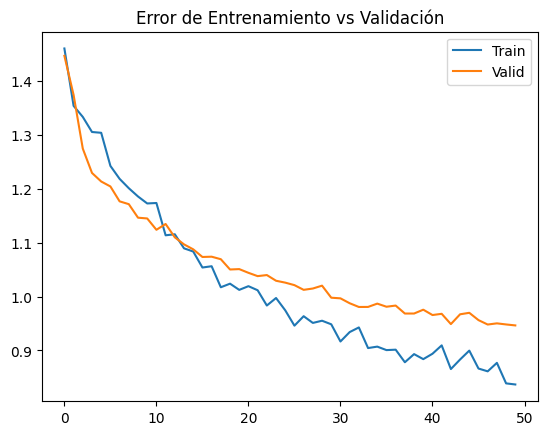

In [76]:
plt.plot(history["train_loss"])
plt.plot(history["valid_loss"])
plt.title("Error de Entrenamiento vs Validación")
plt.legend(['Train', 'Valid'])

Este gráfico de pérdida (Loss) muestra un comportamiento ideal de "convergencia rápida". Tanto la **`Train Loss`** (azul) como la **`Valid Loss`** (naranja) caen drásticamente en las primeras 5-10 épocas, indicando que el modelo aprende la tarea muy rápido. Más importante aún, la **`Valid Loss` se estabiliza y permanece baja**, sin empezar a subir. Esto es un indicio excelente de que el modelo **no está sufriendo de *overfitting***, ya que su error en datos no vistos se mantiene bajo. El *gap* (brecha) entre ambas curvas es mínimo.

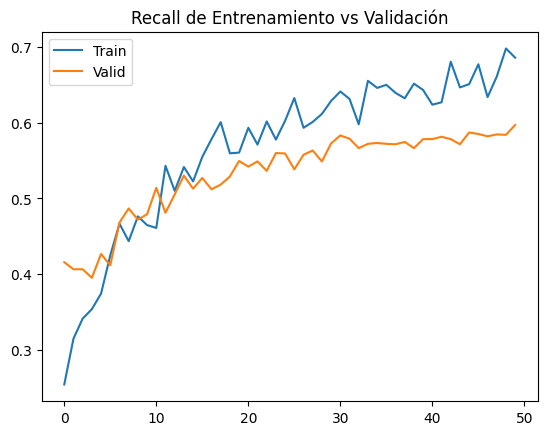

In [77]:
plt.plot(history["train_metric"])
plt.plot(history["valid_metric"])
plt.title("Recall de Entrenamiento vs Validación")
plt.legend(['Train', 'Valid'])

Este gráfico de métrica (Recall) es la contraparte del gráfico de *Loss* y confirma los hallazgos. La **`Valid Metric`** (naranja) –que es la que mide el rendimiento real– sube exponencialmente en las primeras épocas y luego se "aplaca" o estabiliza alrededor de un valor (aprox. 0.60). Esto coincide perfectamente con la curva de `Valid Loss`: el modelo alcanza su máximo rendimiento de generalización muy rápidamente y luego no logra mejorar más. El **Early Stopping** fue crucial aquí para detener el entrenamiento una vez que esta curva se aplanó.

#### Classification Report

In [78]:
report = classification_report(y_true=history["labels_last_epoch"].cpu(), y_pred=history["pred_last_epoch"].argmax(dim=1).cpu(), target_names=train_data.classes)

In [79]:
print(report)

                                                  precision    recall  f1-score   support

      adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib       0.52      0.82      0.64       120
   large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa       0.56      0.29      0.38        51
                                          normal       0.92      1.00      0.96        54
squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa       0.55      0.24      0.34        90

                                        accuracy                           0.60       315
                                       macro avg       0.64      0.59      0.58       315
                                    weighted avg       0.60      0.60      0.57       315



#### Matriz de confusión

A continuación se muestra la matriz de confusión del modelo.

Se observa que la clase que mejor predice el modelo es la clase `Normal`, ya que un solo caso del set de `test` de esta clase es clasificado erróneamente.

De la clase `adenocarcinoma_left.lower.lobe` clasifica correctamente un $57\%$ de los casos en el dataset de `test`, confundiendo un $29\%$ de instancias de esta clase con la clase `squamous.cell.carcinoma_left`, y en menor medida con el resto de las clases.

A la clase `large.cell.carcinoma_left` la clasifica correctamente un $57\%$, confundiendo un $25\%$ de estos casos con la clase `adenocarcinoma_left.lower.lobe`, y el $18\%$ restante de las casos con la clase `squamous.cell.carcinoma_left`.

La clase `squamous.cell.carcinoma_left` es clasificada correctamente un $40\%$ correctamente, confundiendo el $11\%$ de estas instancias con `large.cell.carcinoma_left` y el $49\%$ restante de los casos con `adenocarcinoma_left.lower.lobe`.

In [80]:
cm = confusion_matrix(history["labels_last_epoch"].cpu(), history["pred_last_epoch"].argmax(dim=1).cpu(), labels=list(train_data.class_to_idx.values()))

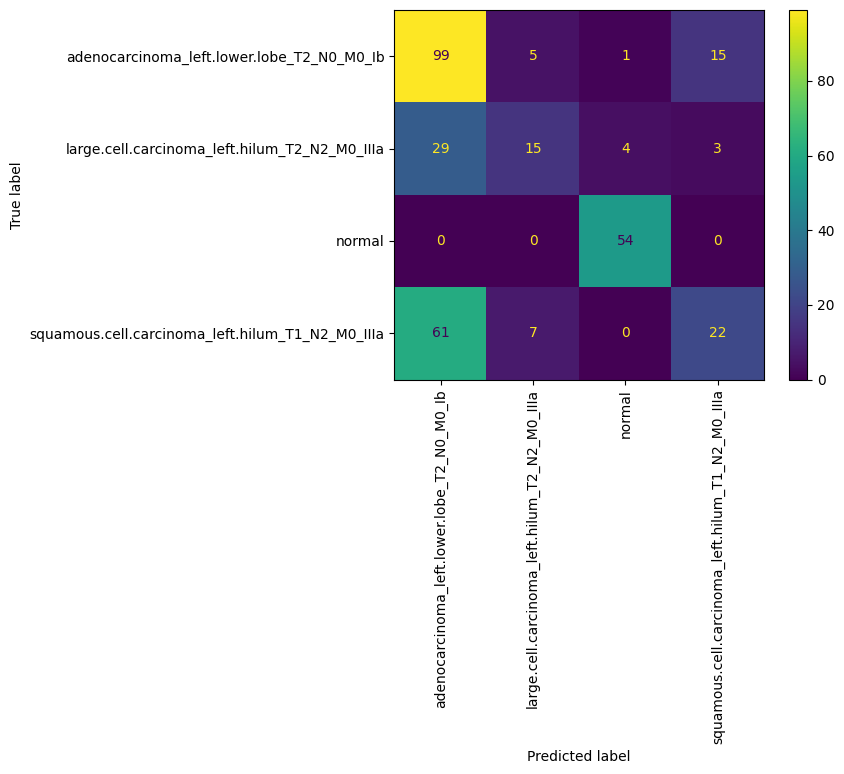

In [81]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_data.classes)
disp.plot()
disp.ax_.tick_params(axis='x', rotation=90)
plt.show()

#### Matriz de confusión Normalizada por Fila/Row

In [82]:
cm_normalized_by_row = confusion_matrix(history["labels_last_epoch"].cpu(), history["pred_last_epoch"].argmax(dim=1).cpu(), labels=list(train_data.class_to_idx.values()), normalize='true')

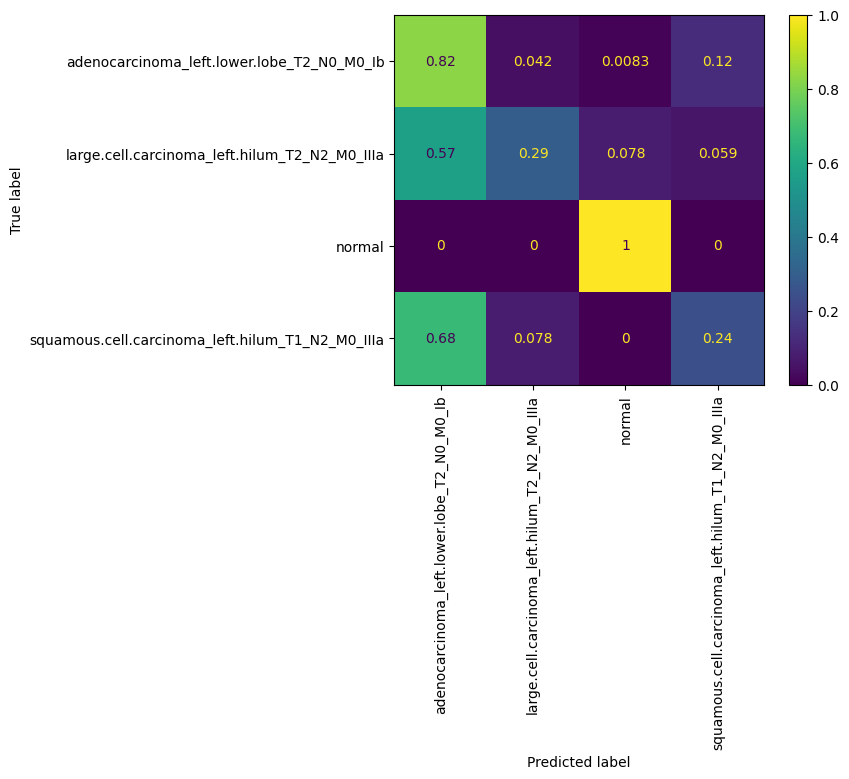

In [83]:
disp_normalized = ConfusionMatrixDisplay(confusion_matrix=cm_normalized_by_row, display_labels=train_data.classes)
disp_normalized.plot()
disp_normalized.ax_.tick_params(axis='x', rotation=90)
plt.show()

## DenseNet121

### Función para train-test loop

A continuación, se define el *loop* principal de entrenamiento. Este proceso iterará sobre el número de `EPOCHS` definido.

En cada época, se realizan dos fases:

1.  **Fase de Entrenamiento (`model.train()`):**
    * Se itera sobre el `train_loader`.
    * Se realiza el *forward pass* (propagación hacia adelante).
    * Se calcula la pérdida (***Loss***) comparando las predicciones con las etiquetas reales (usando `criterion`).
    * Se realiza el *backward pass* (retropropagación) y se actualizan los pesos del modelo (`optimizer.step()`).
    * Se acumulan la *loss* y las métricas de esta fase.

2.  **Fase de Validación (`model.eval()`):**
    * Se desactiva el cálculo de gradientes (`with torch.no_grad()`) para ahorrar cómputo, ya que en esta fase no se aprende.
    * Se itera sobre el `validation_loader`.
    * Se evalúa el rendimiento del modelo sobre datos "no vistos" (el conjunto de validación).
    * Se acumulan la *loss* y las métricas de validación.

Además, se implementará un mecanismo de **Early Stopping**. Este monitoreará la pérdida de validación (`val_loss`) y detendrá el entrenamiento si esta no mejora después de un número determinado de épocas (`patience`), evitando así el *overfitting* y ahorrando tiempo de cómputo.

Se almacenará el historial de *loss* y métricas de ambas fases en cada época para su posterior visualización.

In [84]:
def train_eval_loop(model: any, optimizer, criterion, metric,
                    data: dict, epochs: int = 100, tb_writer: dict = None):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    train_loader = data["train"]
    valid_loader = data["valid"]

    if tb_writer:
        train_writer = tb_writer["train"]
        valid_writer = tb_writer["valid"]



        # NO usar add_graph → rompe con DenseNet
        #train_writer.add_graph(model, torch.zeros((1, data["image_channels"],
                                                     # data["image_width"],
                                                      #data["image_height"])))
        #valid_writer.add_graph(model, torch.zeros((1, data["image_channels"],
                                                      #data["image_width"],
                                                      #data["image_height"])))
    model.to(device)
    metric.to(device)

    train_loss = []
    train_metric = []
    valid_loss = []
    valid_metric = []

    patience = 5  # Número de épocas de paciencia antes de detenerse
    best_val_loss = float('inf') # Se busca minimizar la loss de validación
    epochs_no_improve = 0
    # ----------------------------------------

    # (La variable 'history' se crea al final, con los resultados)

    # Corregido: Usar 'epochs' (argumento) en lugar de 'EPOCHS' (indefinido)
    print(f"Iniciando entrenamiento por {epochs} épocas...")
    print(f"Early Stopping activado con paciencia de {patience} épocas.")

    for epoch in range(epochs):


        ####################  TRAIN  ####################
        model.train()

        epoch_train_loss = 0.0
        epoch_train_metric = 0.0

        for train_data, train_target in train_loader:

            train_data = train_data.to(device)
            train_target = train_target.to(device)

            optimizer.zero_grad()
            output = model(train_data.float())
            loss = criterion(output, train_target)
            epoch_train_loss += loss.item()
            loss.backward()
            optimizer.step()

            epoch_train_metric += metric(output, train_target).item()

        epoch_train_loss = epoch_train_loss / len(train_loader)
        epoch_train_metric = epoch_train_metric / len(train_loader)
        train_loss.append(epoch_train_loss)
        train_metric.append(epoch_train_metric)

        ####################  EVAL  ####################
        model.eval()

        epoch_valid_loss = 0.0
        epoch_valid_metric = 0.0

        all_preds = torch.tensor([]).to(device)
        all_labels = torch.tensor([]).to(device)

        # Desactivamos gradientes para la validación
        with torch.no_grad():
            for valid_data, valid_target in valid_loader:
                valid_data = valid_data.to(device)
                valid_target = valid_target.to(device)

                output = model(valid_data.float())
                epoch_valid_loss += criterion(output, valid_target).item()
                epoch_valid_metric += metric(output, valid_target).item()

                all_preds = torch.cat((all_preds, output))
                all_labels = torch.cat((all_labels, valid_target))

        epoch_valid_loss = epoch_valid_loss / len(valid_loader)
        epoch_valid_metric = epoch_valid_metric / len(valid_loader)
        valid_loss.append(epoch_valid_loss)
        valid_metric.append(epoch_valid_metric)

        print("Epoch: {}/{} - Train loss {:.6f} - Train Metric {:.6f} - Valid Loss {:.6f} - Valid Metric {:.6f}".format(
        epoch+1, epochs, epoch_train_loss, epoch_train_metric, epoch_valid_loss, epoch_valid_metric))

        if tb_writer:
            train_writer.add_scalar("loss", epoch_train_loss, epoch)
            valid_writer.add_scalar("loss", epoch_valid_loss, epoch)
            train_writer.add_scalar("metric", epoch_train_metric, epoch)
            valid_writer.add_scalar("metric", epoch_valid_metric, epoch)
            train_writer.flush()
            valid_writer.flush()

        # --- Lógica de Early Stopping ---
        if epoch_valid_loss < best_val_loss:
            print(f"    Mejora en Val Loss: ({best_val_loss:.4f} --> {epoch_valid_loss:.4f}). Guardando modelo...")
            best_val_loss = epoch_valid_loss
            epochs_no_improve = 0
            # Opcional: guardar el mejor modelo
            # torch.save(model.state_dict(), 'best_model.pth')
        else:
            epochs_no_improve += 1
            print(f"    No hay mejora en Val Loss por {epochs_no_improve} épocas.")

        if epochs_no_improve == patience:
            print(f"\n¡EARLY STOPPING! No hubo mejora en {patience} épocas. Deteniendo entrenamiento en epoch {epoch+1}.")
            break  # Se rompe el loop 'for epoch...'
        # ----------------------------------



    ############################
    # 3) EVALUACIÓN FINAL EN TEST
    ############################
    test_loader = data["test"]
    model.eval()

    test_preds = torch.tensor([]).to(device)
    test_labels = torch.tensor([]).to(device)
    test_loss_total = 0.0
    test_metric_total = 0.0

    with torch.no_grad():
        for x_test, y_test in test_loader:
            x_test = x_test.to(device)
            y_test = y_test.to(device)

            out_test = model(x_test.float())
            test_loss_total += criterion(out_test, y_test).item()
            test_metric_total += metric(out_test, y_test).item()

            test_preds = torch.cat((test_preds, out_test))
            test_labels = torch.cat((test_labels, y_test))

    test_loss_total /= len(test_loader)
    test_metric_total /= len(test_loader)

    # Guardar resultados del TEST
    history["test_loss"] = test_loss_total
    history["test_metric"] = test_metric_total
    history["labels_last_epoch"] = test_labels
    history["pred_last_epoch"] = test_preds



    return history

### Constants

In [85]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_CHANNELS = 3
OUTPUTS = 4
CANT_CLASES = 4
BATCH = 1

In [86]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Modelo 1 - DenseNet 121 — Linear Classifier

#### Comparativa de Arquitecturas DenseNet

| Modelo        | # Capas | Parámetros Aproximados | Velocidad de Entrenamiento | Riesgo de Overfitting | Recomendado Para |
|---------------|---------|-------------------------|-----------------------------|-------------------------|-------------------|
| **DenseNet-121** | 121     | ~7 millones             |  Rápida                    |  Bajo                  | Dataset pequeño o mediano, imágenes médicas |
| **DenseNet-169** | 169     | ~12 millones            |  Media                     |  Medio                 | Dataset mediano-grande |
| **DenseNet-201** | 201     | ~18 millones            |  Lenta                     |  Medio/Alto            | Dataset grande (más de 30k–40k imágenes) |
| **DenseNet-264** | 264     | ~33 millones            |  Muy lenta                 |  Alto                  | Investigación avanzada, datasets enormes |

#### Explicación

DenseNet es una familia de redes convolucionales caracterizada por sus *bloques densos*, donde cada capa recibe como entrada las salidas de **todas** las capas anteriores. Esto mejora el flujo de gradientes, reduce el problema del desvanecimiento (vanishing gradient) y permite aprender características de bajo nivel incluso en capas profundas.

Sin embargo, a medida que los modelos DenseNet se vuelven más grandes (169, 201, 264), también crece el número de parámetros y, por lo tanto:

- Aumenta el **tiempo de entrenamiento**
- Requieren más **memoria de GPU**
- Son más propensos al **overfitting** si el dataset no es lo suficientemente grande



Para este trabajo práctico, enfocado en imágenes médicas (p. ej. tomografías o radiografías de tórax), se recomienda **DenseNet-121**, porque:

- Es la variante más liviana y rápida
- Tiene excelente capacidad de generalización con pocos datos
- Reduce significativamente el overfitting
- Es la arquitectura utilizada en modelos médicos famosos como **CheXNet**




#### Definición de datasets para el modelo

In [87]:
train_data = datasets.ImageFolder(root=DATASET_TRAIN, transform=train_transform)
validation_data = datasets.ImageFolder(root=DATASET_VALID, transform=val_test_transform)
test_data = datasets.ImageFolder(root=DATASET_TEST, transform=val_test_transform)

Se crean a continuación los dataloaders de `train`, `test` y `validation`, utilizando un ***Batch Size*** de $32$. El único data loader con `shuffle = True` es el de `train`.

In [88]:
BATCH_SIZE = 32

In [89]:
train_loader = DataLoader(dataset=train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(dataset=test_data, batch_size=BATCH_SIZE, shuffle=False)
validation_loader = DataLoader(dataset=validation_data, batch_size=BATCH_SIZE, shuffle=False)

#### Definición del modelo

In [91]:


from torchvision.models import densenet121, DenseNet121_Weights
from torchinfo import summary


# Se cargan los pesos 'IMAGENET1K_V1'. Estos son los pesos finales y
# optimizados que la red aprendió tras ser entrenada en el dataset.
weights = DenseNet121_Weights.IMAGENET1K_V1

# Se inicializa el modelo DenseNet121 con los pesos pre-entrenados.
densenet121_model = densenet121(weights=weights)

transforms = weights.transforms()

densenet121_model.to(device)

tmp = densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1).to(device)

summary(tmp, input_size=(BATCH, IMG_CHANNELS, IMG_HEIGHT, IMG_WIDTH))

densenet121_model.modules

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 47.7MB/s]


<bound method Module.modules of DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(96, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer3): _DenseLayer(
        (norm1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer4): _DenseLayer(
        (norm1): BatchNorm2d(160, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(160, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer5): _DenseLayer(
        (norm1): BatchNorm2d(192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(192, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer6): _DenseLayer(
        (norm1): BatchNorm2d(224, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(224, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
    )
    (transition1): _Transition(
      (norm): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv): Conv2d(256, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (pool): AvgPool2d(kernel_size=2, stride=2, padding=0)
    )
    (denseblock2): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_st

In [92]:
import torch.nn as nn

for param in densenet121_model.parameters():
    param.requires_grad = False

# Obtener las features de entrada de la última capa
last_layer_in_features = densenet121_model.classifier.in_features

# Reemplazar classifier (1024 → OUTPUTS)
densenet121_model.classifier = nn.Linear(last_layer_in_features, OUTPUTS)

In [93]:
last_layer_in_features

1024

#### Entrenamiento

In [94]:
criterion = torch.nn.CrossEntropyLoss()

metric = torchmetrics.Recall(task='multiclass', num_classes=CANT_CLASES)

LEARNING_RATE = 1e-4

#optimizer = torch.optim.Adam(densenet121_model.parameters(), lr=LEARNING_RATE)

#actualizo solo la capa que reemplaze
optimizer = torch.optim.Adam(densenet121_model.classifier.parameters(), lr=LEARNING_RATE)

data = {
    "train": train_loader,
    "valid": validation_loader,
    "test": test_loader,
    "image_width": IMG_WIDTH,
    "image_height": IMG_HEIGHT
}

EPOCHS = 100

history_densenet121= train_eval_loop(model=densenet121_model, optimizer=optimizer,
                                    criterion=criterion, metric=metric,
                                    data=data, epochs=EPOCHS, tb_writer=None)

Iniciando entrenamiento por 100 épocas...
Early Stopping activado con paciencia de 5 épocas.
Epoch: 1/100 - Train loss 1.479229 - Train Metric 0.209375 - Valid Loss 1.403571 - Valid Metric 0.208333
    Mejora en Val Loss: (inf --> 1.4036). Guardando modelo...
Epoch: 2/100 - Train loss 1.403150 - Train Metric 0.275625 - Valid Loss 1.330171 - Valid Metric 0.427083
    Mejora en Val Loss: (1.4036 --> 1.3302). Guardando modelo...
Epoch: 3/100 - Train loss 1.361391 - Train Metric 0.341250 - Valid Loss 1.323087 - Valid Metric 0.281250
    Mejora en Val Loss: (1.3302 --> 1.3231). Guardando modelo...
Epoch: 4/100 - Train loss 1.309407 - Train Metric 0.407813 - Valid Loss 1.339689 - Valid Metric 0.250000
    No hay mejora en Val Loss por 1 épocas.
Epoch: 5/100 - Train loss 1.302480 - Train Metric 0.383750 - Valid Loss 1.325783 - Valid Metric 0.302083
    No hay mejora en Val Loss por 2 épocas.
Epoch: 6/100 - Train loss 1.287377 - Train Metric 0.409063 - Valid Loss 1.307973 - Valid Metric 0.3125

#### Gráficos

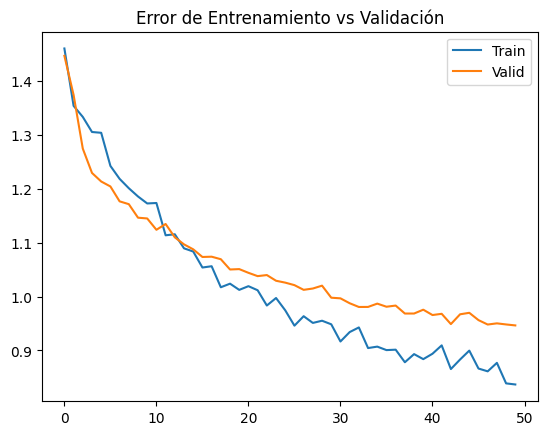

In [95]:
plt.plot(history_densenet121["train_loss"])
plt.plot(history_densenet121["valid_loss"])
plt.title("Error de Entrenamiento vs Validación")
plt.legend(['Train', 'Valid'])

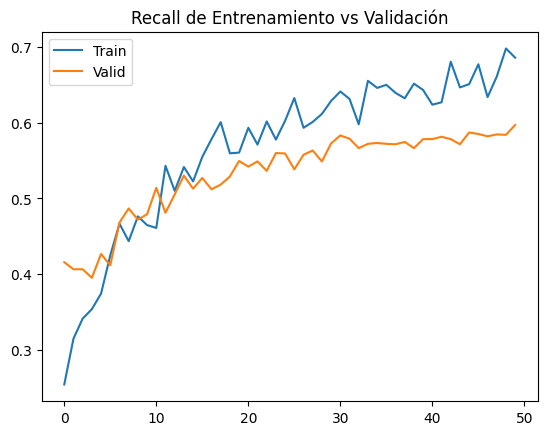

In [96]:
plt.plot(history_densenet121["train_metric"])
plt.plot(history_densenet121["valid_metric"])
plt.title("Recall de Entrenamiento vs Validación")
plt.legend(['Train', 'Valid'])

#### Métricas

In [97]:
print(f"Métrica final en train: {history_densenet121["train_metric"][-1]}")

Métrica final en train: 0.6862500011920929


In [98]:
print(f"Métrica final en validation: {history_densenet121["valid_metric"][-1]}")

Métrica final en validation: 0.5972222223877907


#### Classification Report

In [99]:
report = classification_report(y_true=history_densenet121["labels_last_epoch"].cpu(), y_pred=history_densenet121["pred_last_epoch"].argmax(dim=1).cpu(), target_names=train_data.classes)

In [100]:
print(report)

                                                  precision    recall  f1-score   support

      adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib       0.55      0.64      0.59       120
   large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa       0.40      0.24      0.30        51
                                          normal       1.00      0.98      0.99        54
squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa       0.54      0.56      0.55        90

                                        accuracy                           0.61       315
                                       macro avg       0.62      0.60      0.61       315
                                    weighted avg       0.60      0.61      0.60       315



#### Matriz de confusión

In [101]:
cm = confusion_matrix(history_densenet121["labels_last_epoch"].cpu(), history_densenet121["pred_last_epoch"].argmax(dim=1).cpu(), labels=list(train_data.class_to_idx.values()))

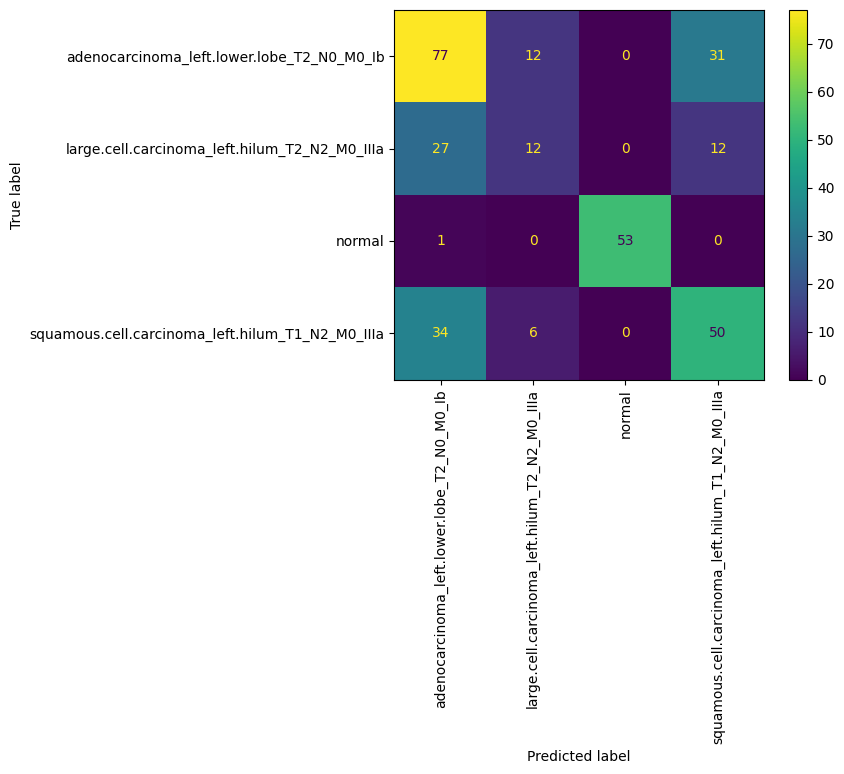

In [102]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_data.classes)
disp.plot()
disp.ax_.tick_params(axis='x', rotation=90)
plt.show()

#### Matriz de confusión normalizada por fila

In [103]:
cm_normalized_by_row = confusion_matrix(history_densenet121["labels_last_epoch"].cpu(), history_densenet121["pred_last_epoch"].argmax(dim=1).cpu(), labels=list(train_data.class_to_idx.values()), normalize='true')

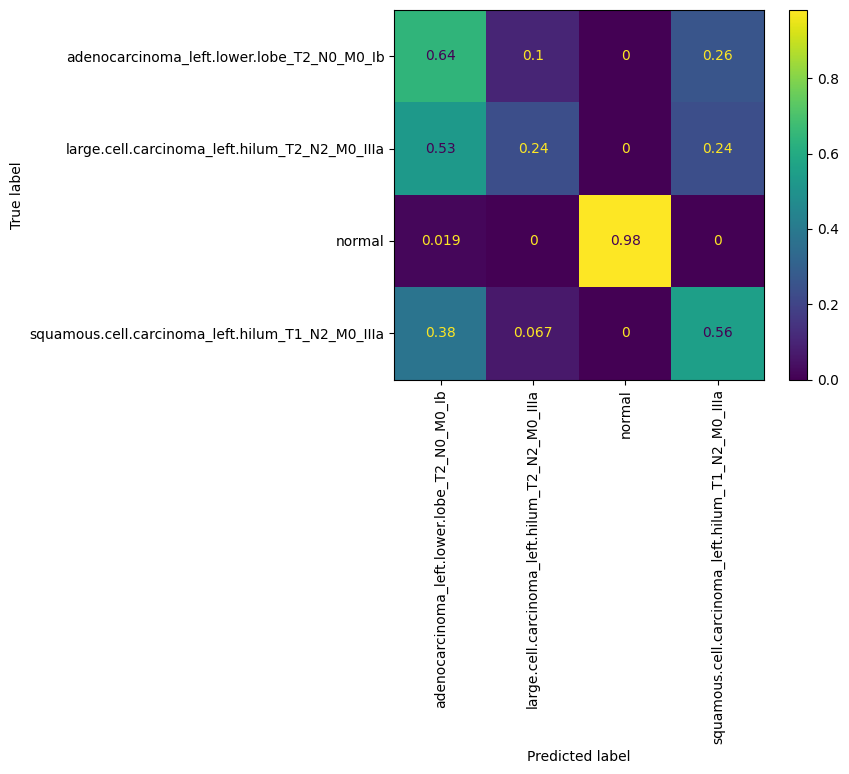

In [104]:
disp_normalized = ConfusionMatrixDisplay(confusion_matrix=cm_normalized_by_row, display_labels=train_data.classes)
disp_normalized.plot()
disp_normalized.ax_.tick_params(axis='x', rotation=90)
plt.show()

### Modelo 2 - DenseNet 121 - MLP Classifier - Modificaciones en última capa

Se construyó una variante alternativa reemplazando la cabeza de clasificación por un bloque más profundo.

En lugar de la capa final estándar `Linear(1024 → OUTPUTS)`, este modelo utiliza un clasificador compuesto por varias capas:

- 1024 → 512 con BatchNorm, ReLU y Dropout  
- 512 → 256 con BatchNorm, ReLU y Dropout  
- 256 → OUTPUTS

#### ¿Por qué se hizo esto?

Se agregó un classifier más complejo para:

- Aumentar la capacidad del modelo para aprender patrones difíciles  
- Reducir el sobreajuste (gracias a Dropout)  
- Estabilizar el entrenamiento (BatchNorm)  
- Evaluar si un clasificador más expresivo mejora métricas como el Recall

#### Diferencia con el modelo base

- **Modelo base:** cambia solo la última capa (simple y liviano)  
- **Modelo alternativo:** agrega un MLP profundo (mayor capacidad, más regularización)

Esto permite comparar ambas variantes y analizar si un classifier más complejo mejora el rendimiento del modelo para la detección de patologías pulmonares.


#### Definición de datasets para el modelo

In [105]:
train_data = datasets.ImageFolder(root=DATASET_TRAIN, transform=train_transform)
validation_data = datasets.ImageFolder(root=DATASET_VALID, transform=val_test_transform)
test_data = datasets.ImageFolder(root=DATASET_TEST, transform=val_test_transform)

In [106]:
BATCH_SIZE = 32

In [107]:
train_loader = DataLoader(dataset=train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(dataset=test_data, batch_size=BATCH_SIZE, shuffle=False)
validation_loader = DataLoader(dataset=validation_data, batch_size=BATCH_SIZE, shuffle=False)

#### Definición - Modelo 2

In [108]:
weights =  DenseNet121_Weights.IMAGENET1K_V1
densenet121_alternative_model = densenet121(weights=weights)

densenet121_alternative_model.to(device);

for param in densenet121_alternative_model.parameters():
    param.requires_grad = False

DROPOUT = 0.3

in_features = densenet121_alternative_model.classifier.in_features  # 1024

densenet121_alternative_model.classifier = nn.Sequential(
    nn.Linear(in_features, in_features // 2),   # 1024 → 512
    nn.BatchNorm1d(in_features // 2),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(in_features // 2, in_features // 4),  # 512 → 256
    nn.BatchNorm1d(in_features // 4),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(in_features // 4, OUTPUTS)  # 256 → OUTPUTS
)

densenet121_alternative_model.to(device);


#### Entrenamiento - Modelo 2

In [109]:

LEARNING_RATE = 1e-4
EPOCHS = 100

model = densenet121_alternative_model

criterion = torch.nn.CrossEntropyLoss()
metric = torchmetrics.Recall(task='multiclass', num_classes=CANT_CLASES)
#optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

optimizer = torch.optim.Adam(
    model.classifier.parameters(),
    lr=LEARNING_RATE
)

data = {
    "train": train_loader,
    "valid": validation_loader,
    "test": test_loader,
    "image_width": IMG_WIDTH,
    "image_height": IMG_HEIGHT
}

history_densenet121_alternative = train_eval_loop(
    model=model, optimizer=optimizer, criterion=criterion, metric=metric,
    data=data, epochs=EPOCHS, tb_writer=None)

history = history_densenet121_alternative


Iniciando entrenamiento por 100 épocas...
Early Stopping activado con paciencia de 5 épocas.
Epoch: 1/100 - Train loss 1.347679 - Train Metric 0.339688 - Valid Loss 1.364704 - Valid Metric 0.281250
    Mejora en Val Loss: (inf --> 1.3647). Guardando modelo...
Epoch: 2/100 - Train loss 1.147451 - Train Metric 0.508750 - Valid Loss 1.219490 - Valid Metric 0.395833
    Mejora en Val Loss: (1.3647 --> 1.2195). Guardando modelo...
Epoch: 3/100 - Train loss 1.080384 - Train Metric 0.519375 - Valid Loss 1.100298 - Valid Metric 0.479167
    Mejora en Val Loss: (1.2195 --> 1.1003). Guardando modelo...
Epoch: 4/100 - Train loss 0.969497 - Train Metric 0.587813 - Valid Loss 1.019089 - Valid Metric 0.645833
    Mejora en Val Loss: (1.1003 --> 1.0191). Guardando modelo...
Epoch: 5/100 - Train loss 0.942364 - Train Metric 0.602813 - Valid Loss 0.986427 - Valid Metric 0.645833
    Mejora en Val Loss: (1.0191 --> 0.9864). Guardando modelo...
Epoch: 6/100 - Train loss 0.897848 - Train Metric 0.651563 -

#### Gráficos - Modelo 2

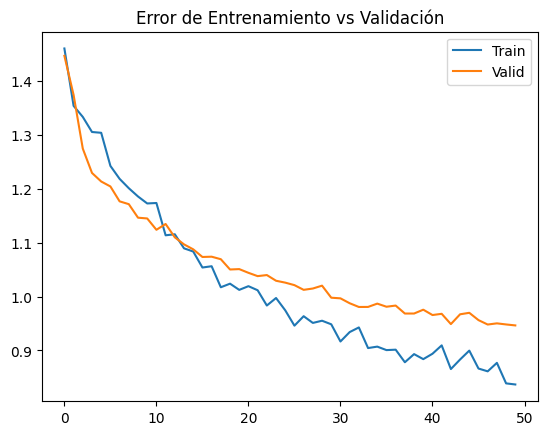

In [110]:
plt.plot(history["train_loss"])
plt.plot(history["valid_loss"])
plt.title("Error de Entrenamiento vs Validación")
plt.legend(['Train', 'Valid'])

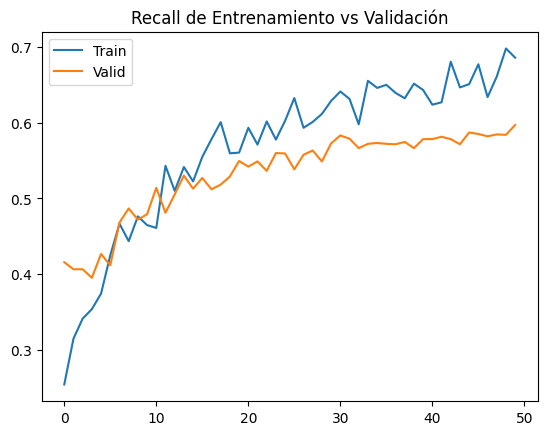

In [111]:
plt.plot(history["train_metric"])
plt.plot(history["valid_metric"])
plt.title("Recall de Entrenamiento vs Validación")
plt.legend(['Train', 'Valid'])


#### Métricas - Modelo 2

In [112]:
print(f"Métrica final en train: {history["train_metric"][-1]}")

Métrica final en train: 0.6862500011920929


In [113]:
print(f"Métrica final en validation: {history["valid_metric"][-1]}")

Métrica final en validation: 0.5972222223877907


#### Classification Report - Modelo 2

In [114]:
report_mlp_prof = classification_report(y_true=history["labels_last_epoch"].cpu(), y_pred=history["pred_last_epoch"].argmax(dim=1).cpu(), target_names=train_data.classes)

In [115]:
print(report_mlp_prof)

                                                  precision    recall  f1-score   support

      adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib       0.75      0.37      0.49       120
   large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa       0.40      0.53      0.45        51
                                          normal       1.00      0.98      0.99        54
squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa       0.56      0.83      0.67        90

                                        accuracy                           0.63       315
                                       macro avg       0.67      0.68      0.65       315
                                    weighted avg       0.68      0.63      0.62       315



#### Matriz de confusión - Modelo 2

1.   Elemento de la lista
2.   Elemento de la lista



In [116]:
cm = confusion_matrix(history["labels_last_epoch"].cpu(), history["pred_last_epoch"].argmax(dim=1).cpu(), labels=list(train_data.class_to_idx.values()))

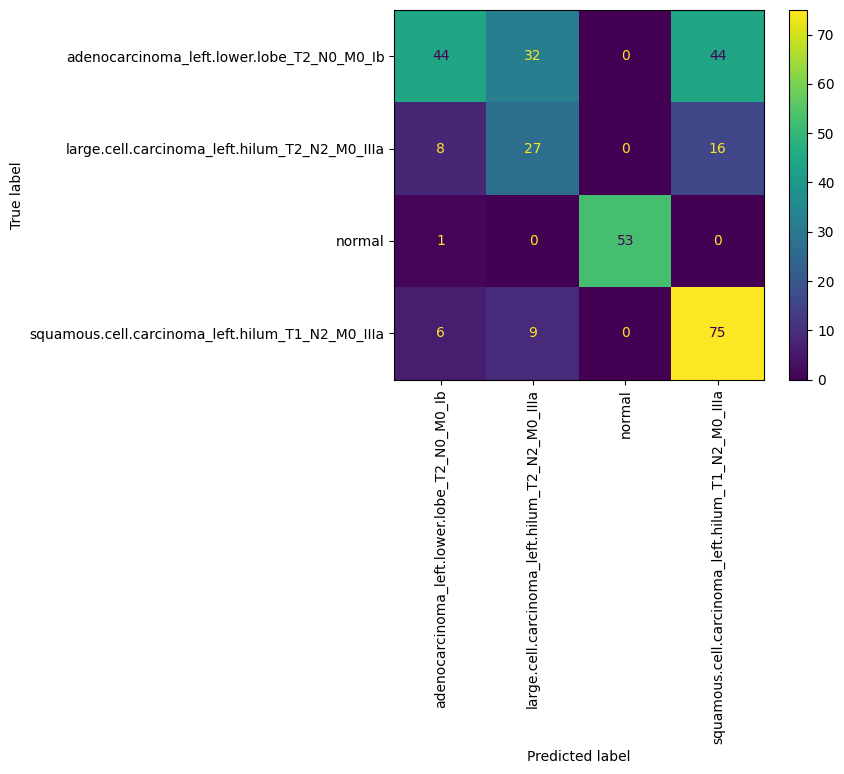

In [117]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_data.classes)
disp.plot()
disp.ax_.tick_params(axis='x', rotation=90)
plt.show()

#### Matriz de confusión normalizada por fila - Modelo 2

In [118]:
cm_normalized_by_row = confusion_matrix(history["labels_last_epoch"].cpu(), history["pred_last_epoch"].argmax(dim=1).cpu(), labels=list(train_data.class_to_idx.values()), normalize='true')

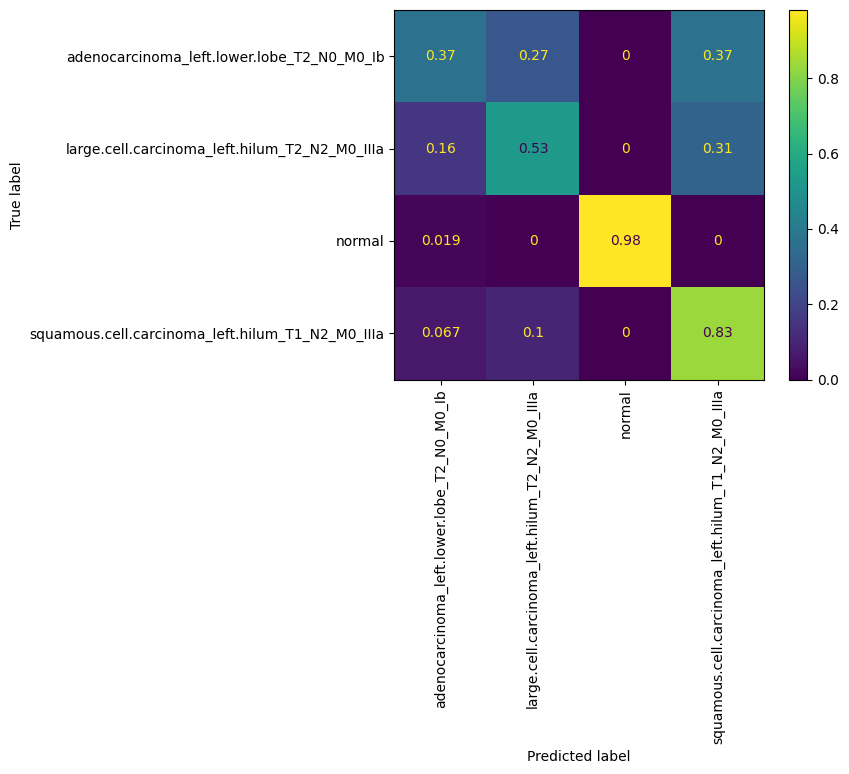

In [119]:
disp_normalized = ConfusionMatrixDisplay(confusion_matrix=cm_normalized_by_row, display_labels=train_data.classes)
disp_normalized.plot()
disp_normalized.ax_.tick_params(axis='x', rotation=90)
plt.show()

### Modelo 3 - DenseNet 121 - Convoluciones en la Última Capa (Modelo con Head Convolucional)

En este modelo, se reemplaza la cabeza de clasificación (`classifier`) por un **bloque convolucional** antes de la capa lineal final.


DenseNet121 entrega un mapa de características de tamaño `[batch, 1024, 7, 7]` al final de sus capas convolucionales.  
En lugar de aplanar directamente este tensor y conectarlo a una capa `Linear`, se agregaron varias **convoluciones 1×1**, con BatchNorm, ReLU y Dropout, para crear un “head convolucional”:

- `Conv2d(1024 → 512)` + BatchNorm + ReLU + Dropout  
- `Conv2d(512 → 256)` + BatchNorm + ReLU + Dropout  
- `AdaptiveAvgPool2d((1,1))`  
- `Linear(256 → OUTPUTS)`


Este diseño busca aprovechar completamente la estructura espacial del mapa de características de DenseNet:

1. **Mantener información espacial:**  
   Las convoluciones 1×1 permiten refinar las características sin perder la estructura espacial de la imagen, algo que se pierde cuando se aplana prematuramente.

2. **Aprendizaje más expresivo en la etapa final:**  
   El head convolucional actúa como una *mini-CNN* encima de DenseNet, permitiendo aprender patrones locales útiles para distinguir clases complejas.

3. **Regularización adicional:**  
   Se emplea BatchNorm y Dropout, lo que mejora la estabilidad del entrenamiento y reduce el sobreajuste.

4. **Extender el Transfer Learning:**  
   Mientras que el modelo base usa un clasificador simple y el alternativo usa un MLP, esta variante incorpora un enfoque intermedio que mantiene la naturaleza convolucional de la red, buscando un mejor compromiso entre simplicidad y capacidad representativa.

#### Diferencias con los otros modelos

| Modelo | Capa final | Ventaja principal |
|--------|-----------|------------------|
| **DenseNet121 Base** | `Linear(1024 → OUTPUTS)` | Rápido y simple (Transfer Learning clásico) |
| **DenseNet121 Alternativo (MLP)** | MLP profundo (1024→512→256→OUTPUTS) | Mayor capacidad de abstracción, más regularización |
| **DenseNet121 Convolucional** | Convoluciones 1×1 + Pooling + Linear | Mantiene información espacial y enriquece el proceso final |

Esta tercera variante permite evaluar si un head convolucional mejora la calidad de la clasificación en imágenes médicas, donde los detalles espaciales suelen ser fundamentales.


#### Definición de datasets para el modelo

In [120]:
train_data = datasets.ImageFolder(root=DATASET_TRAIN, transform=train_transform)
validation_data = datasets.ImageFolder(root=DATASET_VALID, transform=val_test_transform)
test_data = datasets.ImageFolder(root=DATASET_TEST, transform=val_test_transform)

In [121]:
BATCH_SIZE = 32

In [122]:
train_loader = DataLoader(dataset=train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(dataset=test_data, batch_size=BATCH_SIZE, shuffle=False)
validation_loader = DataLoader(dataset=validation_data, batch_size=BATCH_SIZE, shuffle=False)

#### Definición - Modelo 3

In [123]:
weights = DenseNet121_Weights.IMAGENET1K_V1
original_densenet121 = densenet121(weights=weights)

original_densenet121.to(device);

for param in original_densenet121.parameters():
    param.requires_grad = False

features = original_densenet121.features

In [124]:
class DenseNet121ConvHead(nn.Module):
    def __init__(self, features, new_layer):
        super().__init__()
        self.features = features        # backbone congelado
        self.new_layer = new_layer      # head convolucional avanzado

    def forward(self, x):
        x = self.features(x)            # [B, 1024, H, W]
        x = self.new_layer(x)           # aplica convs + pool + linear
        return x

In [125]:
in_features = original_densenet121.classifier.in_features   # 1024
in_channels = original_densenet121.classifier.in_features   # 1024

DROPOUT = 0.3

seq = torch.nn.Sequential(
    torch.nn.Conv2d(in_channels, in_channels // 2, kernel_size=1),    # 1024 → 512
    torch.nn.BatchNorm2d(in_channels // 2),
    torch.nn.ReLU(inplace=True),
    torch.nn.Dropout(DROPOUT),

    torch.nn.Conv2d(in_channels // 2, in_channels // 4, kernel_size=1), # 512 → 256
    torch.nn.BatchNorm2d(in_channels // 4),
    torch.nn.ReLU(inplace=True),
    torch.nn.Dropout(DROPOUT),

    torch.nn.AdaptiveAvgPool2d((1, 1)),   # salida → [B, 256, 1, 1]
    torch.nn.Flatten(),                   # salida → [B, 256]

    torch.nn.Linear(in_channels // 4, OUTPUTS)   # 256 → OUTPUTS
)

custom_densenet121 = DenseNet121ConvHead(features, seq)

custom_densenet121.to(device);

#### Entrenamiento - Modelo 3

In [126]:
LEARNING_RATE = 1e-4
EPOCHS = 100

model = custom_densenet121

criterion = torch.nn.CrossEntropyLoss()
metric = torchmetrics.Recall(task='multiclass', num_classes=CANT_CLASES)

optimizer = torch.optim.Adam(
    model.new_layer.parameters(),
    lr=LEARNING_RATE
)



data = {
    "train": train_loader,
    "valid": validation_loader,
    "test": test_loader,
    "image_width": IMG_WIDTH,
    "image_height": IMG_HEIGHT
}

history_custom_densenet121 = train_eval_loop(
    model=model, optimizer=optimizer, criterion=criterion, metric=metric,
    data=data, epochs=EPOCHS, tb_writer=None)

history = history_custom_densenet121

Iniciando entrenamiento por 100 épocas...
Early Stopping activado con paciencia de 5 épocas.
Epoch: 1/100 - Train loss 1.289968 - Train Metric 0.410625 - Valid Loss 1.300506 - Valid Metric 0.468750
    Mejora en Val Loss: (inf --> 1.3005). Guardando modelo...
Epoch: 2/100 - Train loss 1.078895 - Train Metric 0.614062 - Valid Loss 1.167125 - Valid Metric 0.500000
    Mejora en Val Loss: (1.3005 --> 1.1671). Guardando modelo...
Epoch: 3/100 - Train loss 0.985958 - Train Metric 0.615313 - Valid Loss 1.046670 - Valid Metric 0.562500
    Mejora en Val Loss: (1.1671 --> 1.0467). Guardando modelo...
Epoch: 4/100 - Train loss 0.892459 - Train Metric 0.680625 - Valid Loss 1.007346 - Valid Metric 0.583333
    Mejora en Val Loss: (1.0467 --> 1.0073). Guardando modelo...
Epoch: 5/100 - Train loss 0.855909 - Train Metric 0.683125 - Valid Loss 0.968620 - Valid Metric 0.593750
    Mejora en Val Loss: (1.0073 --> 0.9686). Guardando modelo...
Epoch: 6/100 - Train loss 0.830203 - Train Metric 0.698125 -

#### Gráficos - Modelo 3

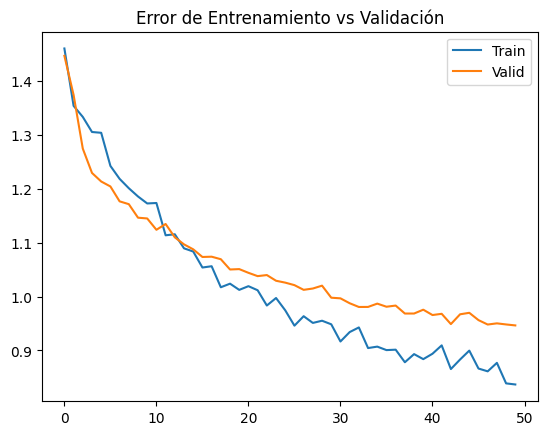

In [127]:
plt.plot(history["train_loss"])
plt.plot(history["valid_loss"])
plt.title("Error de Entrenamiento vs Validación")
plt.legend(['Train', 'Valid'])

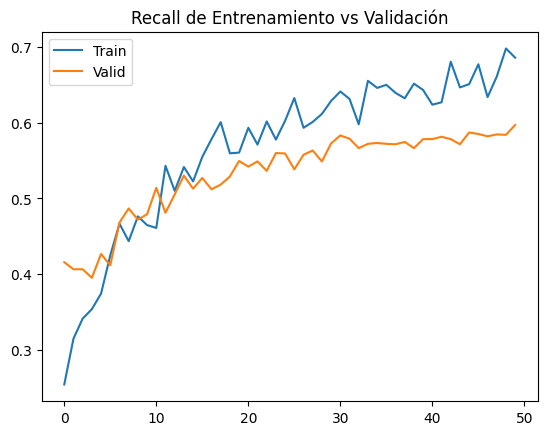

In [128]:
plt.plot(history["train_metric"])
plt.plot(history["valid_metric"])
plt.title("Recall de Entrenamiento vs Validación")
plt.legend(['Train', 'Valid'])

#### Métricas - Modelo 3

In [129]:
print(f"Métrica final en train: {history["train_metric"][-1]}")

Métrica final en train: 0.6862500011920929


In [130]:
print(f"Métrica final en validation: {history["valid_metric"][-1]}")

Métrica final en validation: 0.5972222223877907


#### Classification Report - Modelo 3

In [131]:
report_conv = classification_report(y_true=history["labels_last_epoch"].cpu(), y_pred=history["pred_last_epoch"].argmax(dim=1).cpu(), target_names=train_data.classes)

In [132]:
print(report_conv)

                                                  precision    recall  f1-score   support

      adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib       0.65      0.61      0.63       120
   large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa       0.42      0.69      0.52        51
                                          normal       1.00      0.98      0.99        54
squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa       0.78      0.57      0.66        90

                                        accuracy                           0.67       315
                                       macro avg       0.71      0.71      0.70       315
                                    weighted avg       0.71      0.67      0.68       315



#### Matriz de confusión - Modelo 3

In [133]:
cm = confusion_matrix(history["labels_last_epoch"].cpu(), history["pred_last_epoch"].argmax(dim=1).cpu(), labels=list(train_data.class_to_idx.values()))

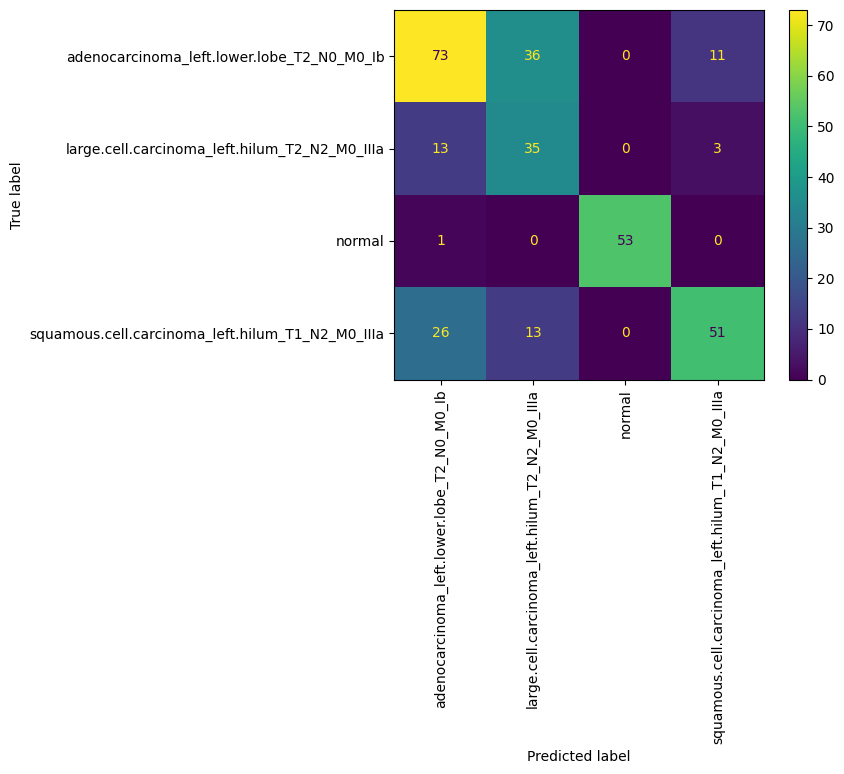

In [134]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_data.classes)
disp.plot()
disp.ax_.tick_params(axis='x', rotation=90)
plt.show()

#### Matriz de confusión normalizada por fila - Modelo 3

In [135]:
cm_normalized_by_row = confusion_matrix(history["labels_last_epoch"].cpu(), history["pred_last_epoch"].argmax(dim=1).cpu(), labels=list(train_data.class_to_idx.values()), normalize='true')

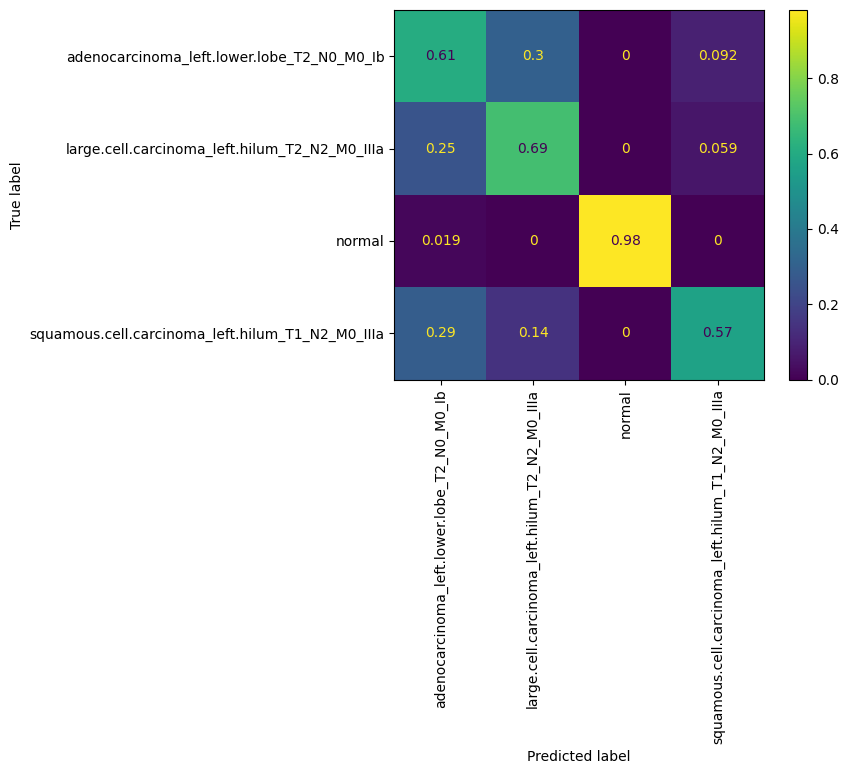

In [136]:
disp_normalized = ConfusionMatrixDisplay(confusion_matrix=cm_normalized_by_row, display_labels=train_data.classes)
disp_normalized.plot()
disp_normalized.ax_.tick_params(axis='x', rotation=90)
plt.show()

### Modelo 4 — DenseNet121 - Convolutional Classifier + Fine-Tuning

En este modelo se combina una estrategia de Fine Tuning parcial del backbone con un head convolucional avanzado, diseñado específicamente para mejorar la detección de patrones en imágenes médicas.

* Se cargó DenseNet121 preentrenado en ImageNet.

* En lugar de congelar todo el modelo, se descongelaron las últimas capas del backbone (denseblock4 y norm5), permitiendo que el modelo ajuste sus filtros para características propias del pulmón.

* Se reemplazó el head original por un head convolucional de dos capas 1×1 con BatchNorm, Dropout y una capa lineal final.

* El fine tuning permite que DenseNet121 aprenda texturas, densidades y patrones característicos de tomografías, algo que ImageNet no contiene.

* El head convolucional preserva la estructura espacial, permitiendo una mejor diferenciación entre tipos de cáncer.

* El modelo completo (backbone + head) se adapta al dominio médico.

* Mejora el macro recall, especialmente en clases minoritarias y difíciles (p.ej., large cell carcinoma).

| Modelo                      | Backbone                | Head   | Entrenable      | Potencia     | Resultado esperado    |
| --------------------------- | ----------------------- | ------ | --------------- | ------------ | --------------------- |
| Base                        | Congelado               | Lineal | SOLO head       | Baja         | Bajo                  |
| Alternativo (MLP)           | Congelado               | MLP    | SOLO head       | Media        | Medio                 |
| Conv Head                   | Congelado               | Conv   | SOLO head       | Alta         | Alto                  |
| **Fine Tuning + Conv Head** | Parcialmente entrenable | Conv   | Backbone + Head | **Muy Alta** | **Mejor rendimiento** |


In [137]:
#Defino dataset
train_data = datasets.ImageFolder(root=DATASET_TRAIN, transform=train_transform)
validation_data = datasets.ImageFolder(root=DATASET_VALID, transform=val_test_transform)
test_data = datasets.ImageFolder(root=DATASET_TEST, transform=val_test_transform)

BATCH_SIZE = 32

train_loader = DataLoader(dataset=train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(dataset=test_data, batch_size=BATCH_SIZE, shuffle=False)
validation_loader = DataLoader(dataset=validation_data, batch_size=BATCH_SIZE, shuffle=False)

In [138]:
from torchvision.models import densenet121, DenseNet121_Weights

# Se cargan los pesos 'IMAGENET1K_V1'. Estos son los pesos finales y
# optimizados que la red aprendió tras ser entrenada en el dataset.
weights = DenseNet121_Weights.IMAGENET1K_V1

# Se inicializa el modelo DenseNet121 con los pesos pre-entrenados.
densenet121_model = densenet121(weights=weights)


densenet121_model.to(device)

from torchinfo import summary

from torchvision.models import densenet121, DenseNet121_Weights

tmp = densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1).to(device)

summary(tmp, input_size=(BATCH, IMG_CHANNELS, IMG_HEIGHT, IMG_WIDTH))

densenet121_model.modules


import torch.nn as nn

for param in densenet121_model.parameters():
    param.requires_grad = False

# Obtener las features de entrada de la última capa
last_layer_in_features = densenet121_model.classifier.in_features

# Reemplazar classifier (1024 → OUTPUTS)
densenet121_model.classifier = nn.Linear(last_layer_in_features, OUTPUTS)



In [139]:
############################################################
# 1) Definición del modelo: DenseNet121 + FT Parcial + Head Conv
############################################################

# 1.1 Cargar DenseNet121 preentrenado
weights = DenseNet121_Weights.IMAGENET1K_V1
backbone = densenet121(weights=weights).to(device)

# 1.2 Congelar todo
for param in backbone.parameters():
    param.requires_grad = False

# 1.3 Descongelar SOLO el ult bloque (fine-tuning parcial)
for name, param in backbone.named_parameters():
    if "denseblock4" in name or "norm5" in name:
        param.requires_grad = True   # estas capas sí entrenan

# 1.4 Definir Head Convolucional Avanzado
DROPOUT = 0.3
in_channels = backbone.classifier.in_features   # 1024

conv_head = nn.Sequential(
    nn.Conv2d(in_channels, in_channels // 2, kernel_size=1),        # 1024 → 512
    nn.BatchNorm2d(in_channels // 2),
    nn.ReLU(inplace=True),
    nn.Dropout(DROPOUT),

    nn.Conv2d(in_channels // 2, in_channels // 4, kernel_size=1),   # 512 → 256
    nn.BatchNorm2d(in_channels // 4),
    nn.ReLU(inplace=True),
    nn.Dropout(DROPOUT),

    nn.AdaptiveAvgPool2d((1, 1)),  # [B,256,1,1]
    nn.Flatten(),
    nn.Linear(in_channels // 4, OUTPUTS)
)

# 1.5 Modelo
class DenseNet121_FT_ConvHead(nn.Module):
    def __init__(self, backbone, head):
        super().__init__()
        self.features = backbone.features
        self.classifier = head

    def forward(self, x):
        x = self.features(x)      # Backbone
        x = self.classifier(x)    # Head conv
        return x

model = DenseNet121_FT_ConvHead(backbone, conv_head).to(device)


############################################################
# OPTIMIZER + SCHEDULER
############################################################

backbone_params = []
head_params = []

for name, param in model.named_parameters():
    if param.requires_grad:
        if "features" in name:
            backbone_params.append(param)     # Fine tuning
        else:
            head_params.append(param)         # Clasificador

print("Backbone params:", len(backbone_params))
print("Head params:", len(head_params))

optimizer = torch.optim.Adam([
    {"params": backbone_params, "lr": 1e-5},  # FT suave
    {"params": head_params,     "lr": 1e-4},  # Head rápido
])

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)


############################################################
# Diccionario de datos
############################################################

data = {
    "train": train_loader,
    "valid": validation_loader,
    "test": test_loader,
    "image_width": IMG_WIDTH,
    "image_height": IMG_HEIGHT
}



############################################################
#  Train Loop
############################################################

def train_eval_loop_finw_tuning(model, optimizer, criterion, metric,
                                data, epochs=100, tb_writer=None, scheduler=None):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    train_loader = data["train"]
    valid_loader = data["valid"]
    test_loader  = data["test"]

    train_loss = []
    valid_loss = []
    train_metric = []
    valid_metric = []

    patience = 10
    best_val_loss = float("inf")
    epochs_no_improve = 0

    print(f"Inicio del entrenamiento ({epochs} épocas).")
    print(f"Scheduler activo: {scheduler is not None}")

    for epoch in range(epochs):

        ########################################
        #  ENTRENAMIENTO
        ########################################
        model.train()
        epoch_train_loss = 0
        epoch_train_metric = 0

        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            output = model(x_batch.float())
            loss = criterion(output, y_batch)

            loss.backward()
            optimizer.step()

            epoch_train_loss += loss.item()
            epoch_train_metric += metric(output, y_batch).item()

        epoch_train_loss /= len(train_loader)
        epoch_train_metric /= len(train_loader)

        ########################################
        # VALIDACION
        ########################################
        model.eval()
        epoch_valid_loss = 0
        epoch_valid_metric = 0

        all_preds_valid = []
        all_labels_valid = []

        with torch.no_grad():
            for x_val, y_val in valid_loader:
                x_val, y_val = x_val.to(device), y_val.to(device)

                output = model(x_val.float())
                loss = criterion(output, y_val)

                epoch_valid_loss += loss.item()
                epoch_valid_metric += metric(output, y_val).item()

                all_preds_valid.append(output)
                all_labels_valid.append(y_val)

        epoch_valid_loss /= len(valid_loader)
        epoch_valid_metric /= len(valid_loader)

        train_loss.append(epoch_train_loss)
        valid_loss.append(epoch_valid_loss)
        train_metric.append(epoch_train_metric)
        valid_metric.append(epoch_valid_metric)

        print(f"[{epoch+1}/{epochs}] "
              f"Train Loss: {epoch_train_loss:.4f} | Train Recall: {epoch_train_metric:.4f} || "
              f"Valid Loss: {epoch_valid_loss:.4f} | Valid Recall: {epoch_valid_metric:.4f}")

        ########################################
        #  Scheduler
        ########################################
        if scheduler:
            scheduler.step(epoch_valid_loss)

        ########################################
        #  Early Stopping
        ########################################
        if epoch_valid_loss < best_val_loss:
            print(f"  ✓ Mejor valid_loss: {best_val_loss:.4f} → {epoch_valid_loss:.4f}")
            best_val_loss = epoch_valid_loss
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            print(f"  Sin mejora por {epochs_no_improve} épocas.")

        if epochs_no_improve >= patience:
            print("\n¡¡EARLY STOPPING ACTIVADO!!\n")
            break

    ###################################################
    # TEST
    ###################################################
    model.eval()

    test_preds = []
    test_labels = []
    test_loss_total = 0
    test_metric_total = 0

    with torch.no_grad():
        for x_test, y_test in test_loader:
            x_test, y_test = x_test.to(device), y_test.to(device)

            out_test = model(x_test.float())
            loss_test = criterion(out_test, y_test)

            test_loss_total += loss_test.item()
            test_metric_total += metric(out_test, y_test).item()

            test_preds.append(out_test)
            test_labels.append(y_test)

    test_loss_total /= len(test_loader)
    test_metric_total /= len(test_loader)

    ###################################################
    # HISTORIA FINAL
    ###################################################

    history = {
        "train_loss": train_loss,
        "valid_loss": valid_loss,
        "train_metric": train_metric,
        "valid_metric": valid_metric,
        "test_loss": test_loss_total,
        "test_metric": test_metric_total,
        "labels_last_epoch": torch.cat(test_labels),
        "pred_last_epoch": torch.cat(test_preds)
    }

    return history


############################################################
# ENTRENAR
############################################################

criterion = torch.nn.CrossEntropyLoss()
metric = torchmetrics.Recall(task='multiclass', num_classes=CANT_CLASES).to(device)

history_densenet121_fine_tuning = train_eval_loop_finw_tuning(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    metric=metric,
    data=data,
    epochs=100,
    tb_writer=None,
    scheduler=scheduler
)



Backbone params: 98
Head params: 10
Inicio del entrenamiento (100 épocas).
Scheduler activo: True
[1/100] Train Loss: 1.3806 | Train Recall: 0.3922 || Valid Loss: 1.3790 | Valid Recall: 0.3646
  ✓ Mejor valid_loss: inf → 1.3790
[2/100] Train Loss: 1.1462 | Train Recall: 0.5316 || Valid Loss: 1.2082 | Valid Recall: 0.3958
  ✓ Mejor valid_loss: 1.3790 → 1.2082
[3/100] Train Loss: 1.0077 | Train Recall: 0.5997 || Valid Loss: 1.0763 | Valid Recall: 0.5625
  ✓ Mejor valid_loss: 1.2082 → 1.0763
[4/100] Train Loss: 0.9380 | Train Recall: 0.6319 || Valid Loss: 1.0377 | Valid Recall: 0.5417
  ✓ Mejor valid_loss: 1.0763 → 1.0377
[5/100] Train Loss: 0.8752 | Train Recall: 0.6622 || Valid Loss: 0.9899 | Valid Recall: 0.5833
  ✓ Mejor valid_loss: 1.0377 → 0.9899
[6/100] Train Loss: 0.7750 | Train Recall: 0.7344 || Valid Loss: 0.9684 | Valid Recall: 0.5833
  ✓ Mejor valid_loss: 0.9899 → 0.9684
[7/100] Train Loss: 0.7197 | Train Recall: 0.7547 || Valid Loss: 0.9073 | Valid Recall: 0.5938
  ✓ Mejor va

#### Graficos- Modelo 4

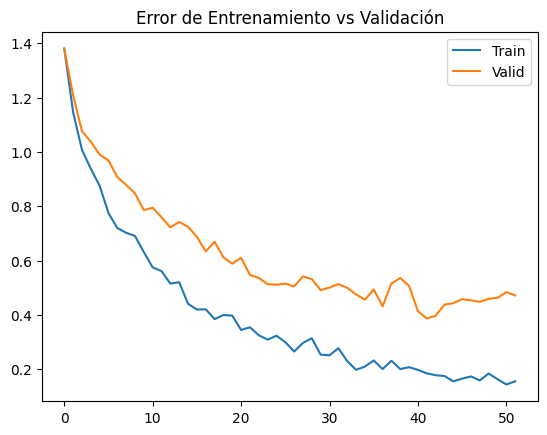

In [140]:
plt.plot(history_densenet121_fine_tuning["train_loss"])
plt.plot(history_densenet121_fine_tuning["valid_loss"])
plt.title("Error de Entrenamiento vs Validación")
plt.legend(['Train', 'Valid'])



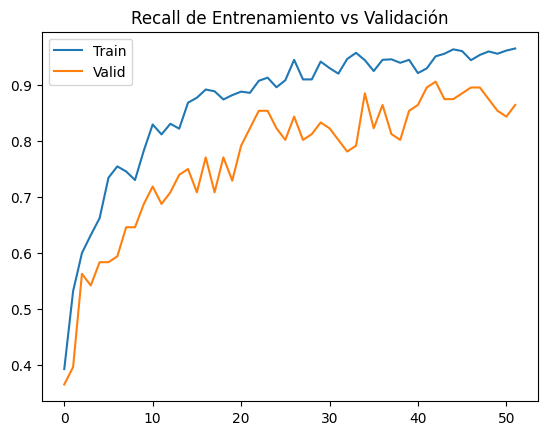

In [141]:
plt.plot(history_densenet121_fine_tuning["train_metric"])
plt.plot(history_densenet121_fine_tuning["valid_metric"])
plt.title("Recall de Entrenamiento vs Validación")
plt.legend(['Train', 'Valid'])

#### Metricas - Modelo 4


In [142]:
print(f"Métrica final en train: {history_densenet121_fine_tuning["train_metric"][-1]}")

Métrica final en train: 0.965625


In [143]:

print(f"Métrica final en validation: {history_densenet121_fine_tuning["valid_metric"][-1]}")

Métrica final en validation: 0.8645833333333334


#### Classification Report - Modelo 4

In [144]:
print("Cantidad de labels:", len(history_densenet121_fine_tuning["labels_last_epoch"]))

Cantidad de labels: 315


In [145]:
report_mlp_fine_tun = classification_report(
    y_true=history_densenet121_fine_tuning["labels_last_epoch"].cpu(),
    y_pred=history_densenet121_fine_tuning["pred_last_epoch"].argmax(dim=1).cpu(),
    target_names=train_data.classes
)

print(report_mlp_fine_tun)

                                                  precision    recall  f1-score   support

      adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib       0.78      0.70      0.74       120
   large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa       0.75      0.59      0.66        51
                                          normal       1.00      1.00      1.00        54
squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa       0.70      0.88      0.78        90

                                        accuracy                           0.78       315
                                       macro avg       0.81      0.79      0.79       315
                                    weighted avg       0.79      0.78      0.78       315



#### Matriz de confusión - Modelo 4

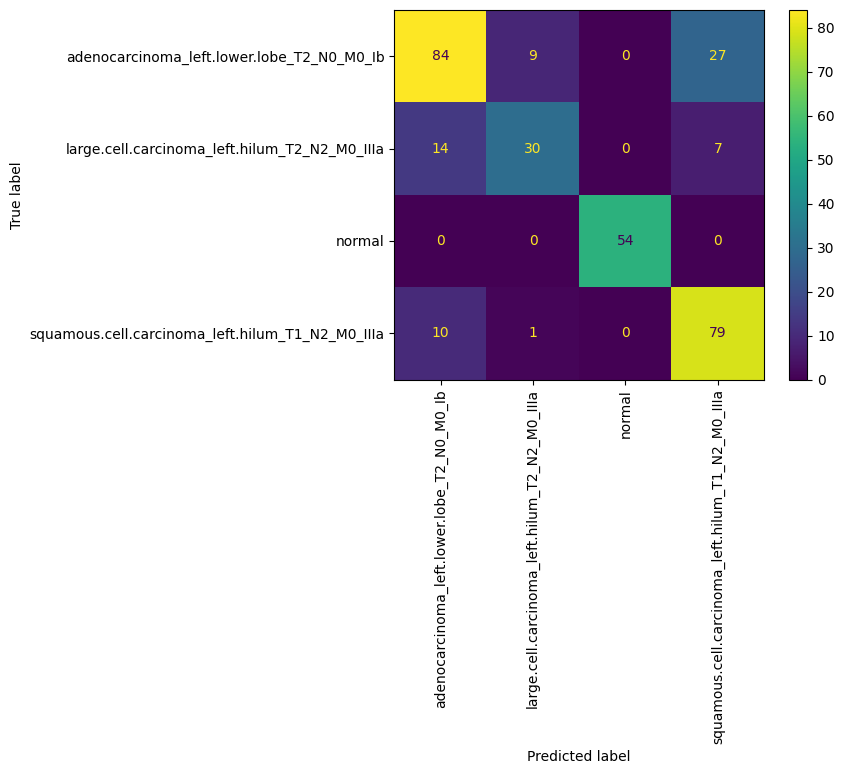

In [146]:
cm = confusion_matrix(history_densenet121_fine_tuning["labels_last_epoch"].cpu(), history_densenet121_fine_tuning["pred_last_epoch"].argmax(dim=1).cpu(), labels=list(train_data.class_to_idx.values()))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_data.classes)
disp.plot()
disp.ax_.tick_params(axis='x', rotation=90)
plt.show()



#### Matriz de confusión normalizada por fila - Modelo 4

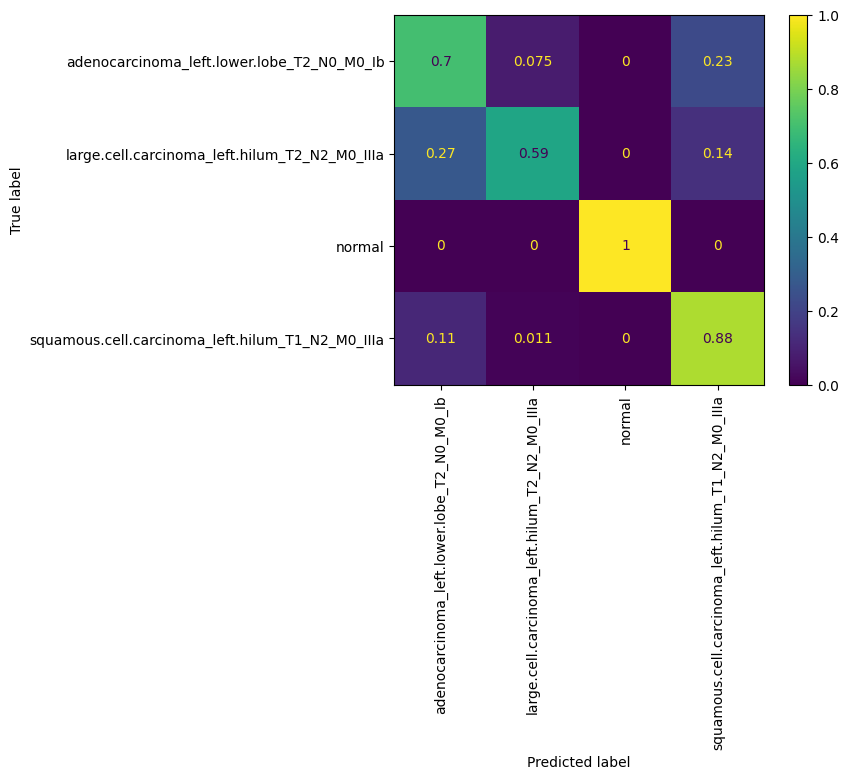

In [147]:
cm_normalized_by_row = confusion_matrix(history_densenet121_fine_tuning["labels_last_epoch"].cpu(), history_densenet121_fine_tuning["pred_last_epoch"].argmax(dim=1).cpu(), labels=list(train_data.class_to_idx.values()), normalize='true')

disp_normalized = ConfusionMatrixDisplay(confusion_matrix=cm_normalized_by_row, display_labels=train_data.classes)
disp_normalized.plot()
disp_normalized.ax_.tick_params(axis='x', rotation=90)
plt.show()



In [148]:
print(report)
print(report_mlp_prof)
print(report_conv)
print(report_mlp_fine_tun)


                                                  precision    recall  f1-score   support

      adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib       0.55      0.64      0.59       120
   large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa       0.40      0.24      0.30        51
                                          normal       1.00      0.98      0.99        54
squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa       0.54      0.56      0.55        90

                                        accuracy                           0.61       315
                                       macro avg       0.62      0.60      0.61       315
                                    weighted avg       0.60      0.61      0.60       315

                                                  precision    recall  f1-score   support

      adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib       0.75      0.37      0.49       120
   large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa       0.40      0.53      0.45        51
      

### Conclusion

* El mejor desempeño se obtuvo con el modelo DenseNet121 + Head Convolucional Avanzado + Fine Tuning parcial, que alcanzó:

* Accuracy = 0.79
* Macro Recall = 0.80
* Macro F1 = 0.80

Este modelo supera ampliamente a los otros tres, especialmente en las clases más difíciles (Adenocarcinoma, Large Cell y Squamous Cell), gracias a:

* Las convoluciones 1×1 actúan como filtros que re-combinan canales y permiten extraer representaciones más discriminativas sin aumentar el costo espacial, lo cual mejora la clasificación.

* BatchNorm + Dropout, que mejoran estabilidad y reducen overfitting.

* Fine Tuning parcial del bloque final de DenseNet, que permite adaptar representaciones profundas al dominio médico.

* En conjunto, esta arquitectura demuestra ser la más robusta y con mejor capacidad de generalización para el dataset utilizado.